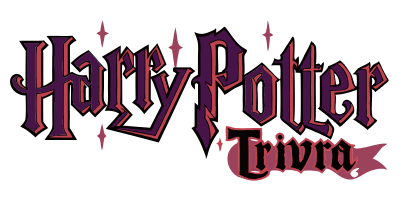

---
<h2 style="text-align:center;">Harry Potter Trivia Game</h2>
<h3 style="text-align:center;">Data preparation and EDA</h3>

---

## 1. Introduction

The goal of this project is to create an engaging Harry Potter Trivia game. This notebook focuses on the foundational step: cleaning and exploring the public dataset that will power the game's content.

The Harry Potter Trivia game will be built using a public dataset of trivia questions from Huggingface. The dataset was downloaded using the `download_data.py` script, the train and test split were combined and stored as a single csv file from [saracandu/harry-potter-trivia-human](https://huggingface.co/datasets/saracandu/harry-potter-trivia-human/tree/main) on January 25, 2025. 

The primary objective of *this notebook* is to clean the dataset and perform exploratory data analysis (EDA) to understand its characteristics and prepare it for potential downstream use (e.g., game logic, model training) and create a clean csv file that can be used in the Phase-1 version of the CLI-MVP of the game.

#### Workflow Summary

The main stages covered in this notebook include:
1. **Data Preparation:** Cleaning and preparing the raw trivia data (handling nulls, duplicates, types, feature selection).
2. **Basic Exploratory Data Analysis (EDA):** Initial analysis and visualization of the questions and answers in the cleaned dataset.
3. **Keyword Generation:** Tokenizing question and answer text using lemmatization to create keyword features.
3. **In-depth EDA:** Grandular analysis and visualization of the cleaned dataset with the generated keywords.
4. **Finalize dataset for CLI-MVP:** Create a clean dataset csv file that can be used in the phase-1, CLI-MVP version of the game.  Provide a basis for expanding the trivia question and answer dataset in future development phases.


## Table of Contents

1. [Introduction](#1-Introduction)<br>
2. [Setup and imports](#2-Setup-and-imports)<br>
3. [Data preparation](#3-data-preparation)<br>
    **PART-1**: Basic EDA<br>
4. [Basic Exploratory Data Analysis (EDA)](#4-Basic-EDA-of-the-cleaned-dataset)<br>
    4.1. [Overview](#41-Overview)<br>
    4.2. [Answer lengths](#42-Answer-lengths)<br>
    4.3. [Question lengths](#43-Questions-lengths)<br>
    4.4. [Question and answer correlations](#44-Question-and-answer-correlation)<br>
    **PART-2**: Feature engineering<br>
5. [Keyword feature engineering](#5-Keyword-feature-engineering) <br>
    **PART-3**: In-depth EDA with keywords and N-grams <br>
6. [EDA based on keywords](#6-EDA-based-on-keywords)<br>
    6.1. [Unique keyword frequency](#61-unique-keyword-frequency) <br>
    6.2. [Factual recall questions](#62-factual-recall-questions)<br>
    6.3. [Questions that do not have factual recall keywords](#63-questions-that-do-not-have-factual-recall-keywords)<br>
    6.4. [Common N-grams in the dataset](#64-common-n-grams-in-the-dataset)
7. [Extending the dataset with new question categorization columns](#7-Extending-the-dataset-with-new-question-categorization-columns)<br>
8. [Summary](#8-Summary)<br>
9. [Key findings](#9-Key-findings)<br>
    **PART-4**: Finalizing dataset for CLI-MVP<br>    
10. [Data dictionary](#10-Data-dictionary)<br>
11. [Next steps](#11-Next-steps)<br>

## 2. Setup and imports

Import the necessary external packages.

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import re
from scipy.stats import shapiro
from collections import Counter, OrderedDict
from typing import Union

from nltk import pos_tag
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

Import the internal environment configuration file.

In [2]:
# Import the project environment configurations and load them.
import dotenv
dotenv.load_dotenv()  

True

Finally, import the custom utility module to manage file paths for this project.

In [3]:
from utils import utils_paths as up
import eda_scripts as eda
# Initialize counter to update figure number automatically for the visuals:
figure_count = 0

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 3. Data preparation

In [4]:
# convert csv file to dataframe
project_root = up.find_project_root()
rawcsv_path = project_root / "data" / "original_dataset_DONT_TOUCH"/"harry_potter_trivia_questions_HFdataset.csv"
raw_df = pd.read_csv(rawcsv_path)
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1279 entries, 0 to 1278
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  1279 non-null   object
 1   answer    1279 non-null   object
 2   text      1279 non-null   object
dtypes: object(3)
memory usage: 30.1+ KB


There are 1279 rows and 3 columns. 

In [5]:
raw_df.sample(5)

,question,answer,text
935,Which plant's pus clears up acne?,Bubotuber,<s>[INST] Which plant's pus clears up acne? [/...
344,How many staircases does Hogwarts have?,142,<s>[INST] How many staircases does Hogwarts ha...
446,How many times did Wendelin the Weird allow he...,Forty-Seven,<s>[INST] How many times did Wendelin the Weir...
969,A Nimbus is a type of what?,Broom,<s>[INST] A Nimbus is a type of what? [/INST] ...
985,Who is the Divination professor?,Professor Trelawney,<s>[INST] Who is the Divination professor? [/I...


We have the question and answers in the first two columns. Let's look at the `text` columnn data for the first row:

In [6]:
# Look at the contents of the first row, third column record (i.e. text column) without being clipped.
print(raw_df.iloc[0,2])  

<s>[INST] What are the three European wizarding schools that participate in the Triwizard Tournament? [/INST] Hogwarts, Beauxbatons, and Durmstrang. </s>


The third column is used for NLP training and we don't need it for this game. So we can get rid of it.

In [7]:
# Drop the `text` column:
raw_df = raw_df.drop(columns=['text'])
print(raw_df.columns)

Index(['question', 'answer'], dtype='object')


In [8]:
# lets check for nulls, just to be sure.
raw_df.isna().sum()

question    0
answer      0
dtype: int64

In [9]:
# check for duplicates
raw_df.duplicated().sum()

np.int64(194)

Let's take a quick look at the duplicated row counts and also make sure that they are duplicates.

In [10]:
# Find duplicates based on all columns
duplicates = raw_df[raw_df.duplicated(keep=False)]

# Count occurrences of each duplicate row
duplicate_counts = duplicates.groupby(duplicates.columns.tolist()).size().reset_index(name='Count')

# Display the counts of each duplicate
print(duplicate_counts)

                                             question           answer  Count
0                       A Firebolt is a type of what?            Broom      5
1                         A Nimbus is a type of what?            Broom      5
2   According to Madam Hooch, which of the followi...        Long hair      5
3   Before Dumbledore, who was Headmaster of Hogwa...   Armando Dippet      2
4        Catching what object ends a Quidditch match?    Golden Snitch      5
..                                                ...              ...    ...
64  Who previously held Snape's post as Potions Ma...  Horace Slughorn      2
65                  Who previously held Snape's post?  Horace Slughorn      2
66  Who was the first witch or wizard to hatch a b...   Herpo the Foul      2
67        Why would you need to switch brooms midair?    Broom failure      5
68  You wouldn't know anything about this. Name a ...     Using polish      5

[69 rows x 3 columns]


If we sort the rows then the duplicates will show up together. 

In [11]:
# Sort `raw_df' by the `question` column
raw_sorted = raw_df.sort_values(by='question')
raw_sorted

,question,answer
28,"""Lemon Drop"" is the password to whose office?",Dumbledore
1009,A Firebolt is a type of what?,Broom
116,A Firebolt is a type of what?,Broom
1139,A Firebolt is a type of what?,Broom
1074,A Firebolt is a type of what?,Broom
...,...,...
1065,You wouldn't know anything about this. Name a ...,Using polish
1091,You wouldn't know anything about this. Name a ...,Using polish
3,You wouldn't know anything about this. Name a ...,Using polish
461,You wouldn't know anything about this. Name a ...,Using polish


In [12]:
trivia_df = raw_df.drop_duplicates(keep='first')

In [13]:
trivia_df.shape

(1085, 2)

After dropping the duplicates, we have 1085 unique questions left.

In [14]:
trivia_df.head()

,question,answer
0,What are the three European wizarding schools ...,"Hogwarts, Beauxbatons, and Durmstrang."
1,When was Hogwarts founded?,10th century
2,What is a Wronski Feint?,Pretending to dive for the Snitch
3,You wouldn't know anything about this. Name a ...,Using polish
4,Harry first took the Knight Bus in The Prisone...,14 sickles.


---

#### 💾 Checkpoint 1: saving clean dataset
<details>
<summary> Click here for checkpoint details and <b>warning!</b> </summary>

The DataFrame is now cleaned and ready for EDA. Saving the current state.
<br>
> **⚠️ Caution: Manual Intervention Required for Saving Files**
>
> Please be aware that the `save_dataframe_to_csv` utility is designed to prevent accidental data loss. It **does not automatically overwrite** previously saved files.
>
> If you run a cell that calls this function and the output file (based on `filename_base`, `version`, and `subfolder`) already exists, the save operation will be skipped. You will see a message indicating this.
>
> **To save your latest data, you must manually intervene by either:**
> 1.  Deleting the older version of the CSV file from the file system.
> 2.  Modifying the `version` argument (or `filename_base`) in your function call to create a new, unique filename.

The following code saves the cleaned DataFrame to <code>data/project_datasets/</code> based on the selecte saved arguments.
</div>
</details>

In [15]:
# Using utils.paths.py module -> prevents overwritting csv file unless manually done.

# Save arguments
dataframe_to_save = trivia_df
name_for_csvfile = 'clean_trivia_dataset'
csv_version = 'v0'
csv_subfolder = 'project_datasets'

# Save csv  file with custom functions and defined save arguments
up.save_dataframe_to_csv(dataframe_to_save, name_for_csvfile, csv_version, csv_subfolder)

File already exists at: data/project_datasets/clean_trivia_dataset_v0.csv. Skipping save.


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

---

<div align="center">
    <span style="color:purple; font-size:32px;">Part-1: Basic Exploratory Data Analysis (EDA)</span>
</div>

## 4. Basic EDA of the cleaned dataset


    - Basic descriptive statistics 
    - Question and Answer length distribution & Textual analysis (word count, average number of words per sentence)
    - Question type classification (Yes/No, open-ended, factual, opinon-based, or mixed?)
    - Answer completeness (are short answers correct or incomplete? any missing answers?)
    - Question and answer correlations (Length of answers by question length / type, answer relevance)
    - Topic modelling and keyword analysis (unique words / vocabulary size, frequent words) -> keyword extraction / Latent Dirichlet Allocation (LDA)?
    - Context analysis (is from all HP corpus or just certain books?)  

### 4.1. Overview

In [16]:
# Let's look at the lengths of questions:

# extract the length of each question
question_lengths = trivia_df["question"].str.split(pat=" ").apply(len)
answer_lengths = trivia_df["answer"].str.split(pat=" ").apply(len)

length_analysis = pd.DataFrame({"question": question_lengths, "answer": answer_lengths}).describe()
print(length_analysis)

          question       answer
count  1085.000000  1085.000000
mean      9.544700     2.564055
std       4.185844     2.529676
min       3.000000     1.000000
25%       7.000000     1.000000
50%       9.000000     2.000000
75%      11.000000     3.000000
max      30.000000    24.000000


The answers are generally shorter then the questions. Most answers are about 1 to 3 words while most questoins are about 9 words. 

We can also look at the distributions visually.

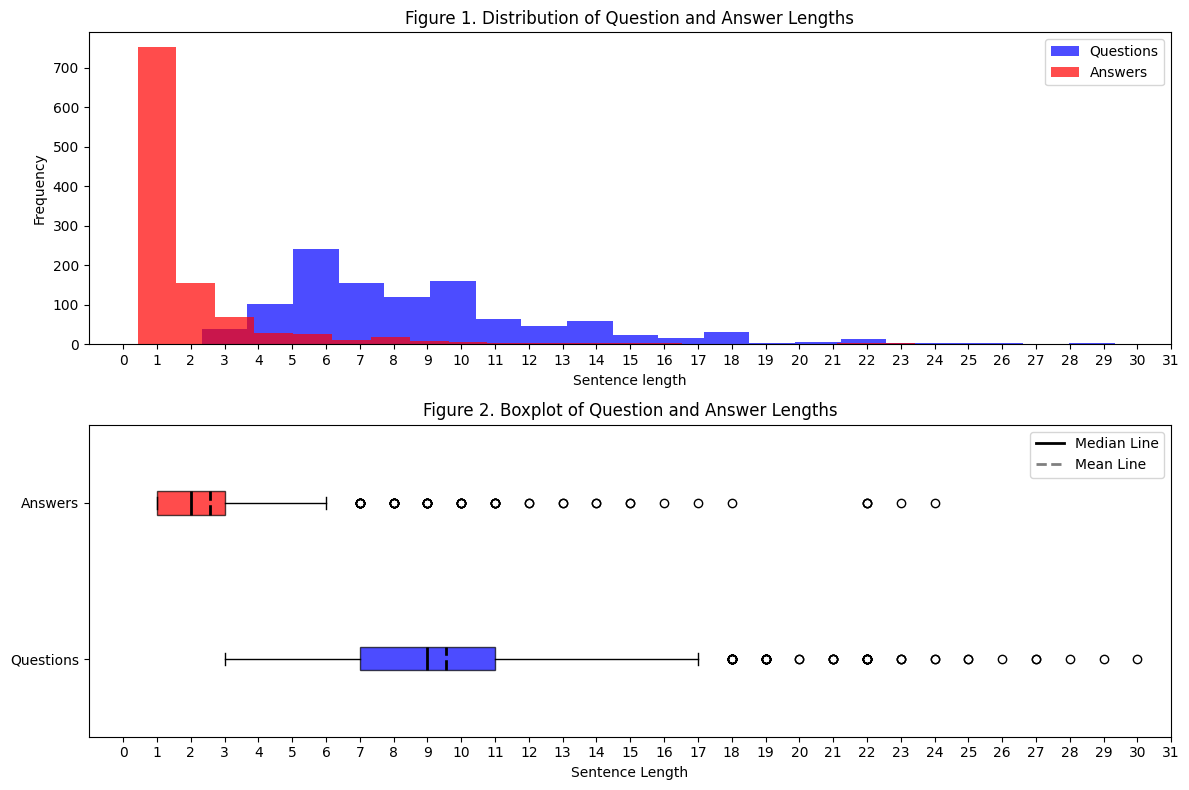

In [17]:
# let's plot the distribution of lengths of questions and answers

# A 1x2 grid of plots
fig, axs = plt.subplots(2,1,figsize=(12, 8))

# PLOT 1: Plot a histogram of the distribution of question lengths
# update figure_count for visual:
figure_count += 1
axs[0].hist(question_lengths, bins=20, color='blue', alpha=0.7,align='left')
# Plot the distribution of answer lengths
axs[0].hist(answer_lengths, bins=20, color='red', alpha=0.7,align='left')
# Formatting
axs[0].set_title(f"Figure {figure_count}. Distribution of Question and Answer Lengths")
axs[0].set_xlabel("Sentence length")
axs[0].set_ylabel("Frequency")
axs[0].legend(["Questions", "Answers"])

# PLOT 2: Boxplot for question and answer lengths
# update figure_count for visual:
figure_count += 1
box = axs[1].boxplot([question_lengths, answer_lengths], vert=False, patch_artist=True,
               tick_labels=["Questions", "Answers"],
               boxprops=dict(color="black"),  # Box border color
               medianprops=dict(color="black", linewidth=2),  # Median line in black
               meanline=True, showmeans=True, meanprops=dict(color="black", linewidth=2)
               )
# Fill colors for boxes
colors = ["blue", "red"]
for patch, color in zip(box["boxes"], colors):
    patch.set(facecolor=color, alpha=0.7)  # Set fill color
axs[1].set_title(f"Figure {figure_count}. Boxplot of Question and Answer Lengths")
axs[1].set_xlabel("Sentence Length")
# Create legend handles
legend_elements = [
    Line2D([0], [0], color="black", linewidth=2, label="Median Line"),
    Line2D([0], [0], color="black", linewidth=2, linestyle="--", label="Mean Line", alpha=0.5)
]
# Add legend to boxplot
axs[1].legend(handles=legend_elements, loc="upper right")

# Ensure both plots have the same x-axis range
axs[1].set_xlim(axs[0].get_xlim())
# Set x-axis ticks to go up in unit steps
axs[0].set_xticks(range(int(min(question_lengths & answer_lengths)), int(max(question_lengths | answer_lengths)) + 1))
axs[1].set_xticks(range(int(min(question_lengths & answer_lengths)), int(max(question_lengths | answer_lengths)) + 1))

plt.tight_layout()
plt.show()

From the plot above:
- Both questions and answers have longer sentences as outliers, perhaps they can be made more concise / clearer?
- The questions looks like a right-skewed normal distribution
- Most questions are ~17 words or less (75% percentile)
- Most questions fall between 7 and 11 words (inter-quartile range)
- The answers is also a very right-skewed distribution with a rapid decay.
- Most answers are ~6 words or less (75% percentile)
- One word answers are the most common. 


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

### 4.2. Answer lengths
Let's start by taking a closer look at the word count frequencies of the answers.

In [18]:
# Frequency of answers based on word count
answers_wordcount = answer_lengths.value_counts()

# total word count:
total_word_count = answers_wordcount.sum()

# Percentage of word counts with 1-3 words, 4-11 words, and 12+ words:
percentage_4to11_wc = (answers_wordcount.loc[(answers_wordcount < 154) & (answers_wordcount >= 6) ].sum() / total_word_count) * 100
percentage_12plus_wc = (answers_wordcount.loc[answers_wordcount < 6].sum() / total_word_count) * 100
percentage_1to3_wc = (answers_wordcount.loc[answers_wordcount >= 154].sum() / total_word_count) * 100

# Display the results:
print(f'Total word count: {total_word_count}')
# Sum the frequency of all answer lengths that have more than 3 words, ie. count less then 154.
print(f'\nThe number of answers with a word count more than 3: {answers_wordcount.loc[answers_wordcount < 154 ].sum()}')
print(f'\nPercentage of answers with word count between 1 and 3: {percentage_1to3_wc:.2f}%')
print(f'\nPercentage of answers with word count between 4 and 11: {percentage_4to11_wc:.2f}%')
print(f'\nPercentage of answers with word count 12 or more: {percentage_12plus_wc:.2f}%')
print(f'\nWord count occurence in answers:\n\n{answers_wordcount}')

Total word count: 1085

The number of answers with a word count more than 3: 179

Percentage of answers with word count between 1 and 3: 83.50%

Percentage of answers with word count between 4 and 11: 15.02%

Percentage of answers with word count 12 or more: 1.47%

Word count occurence in answers:

answer
1     381
2     371
3     154
4      69
5      28
6      25
7      10
8       9
9       9
10      7
11      6
22      3
14      2
13      2
12      2
15      2
23      1
17      1
16      1
18      1
24      1
Name: count, dtype: int64


We can note that:
1. Majority of the answers are 1 to 3 words (75% percentile, 84% frequency count)
2. The remaining answers mostly fall within 4 to 11 word counts (15% frequency count) with the rest with 12 or more words occuring only ~1%.

Let's take a closer look at answers with 3 or less words, especially when only 1.

#### 4.2.1. Short answers:

In [19]:
# Filter short answers
short_answers = trivia_df[answer_lengths < 4]

# filter by word_counts
answer_n_wc = {n: trivia_df[answer_lengths == n] for n in [1, 2, 3]}

# Number of unique words for each word count occurence:
unique_answers = {n: answer_n_wc[n]['answer'].nunique() for n in range(1, 4)}

# Extract frequency occurence for answers with 1,2, and 3 words explicitly
total_by_wc = answers_wordcount.loc[[1,2,3]]

# Display results
print(f"There are {short_answers.shape[0]} answers with one to three words and of those {total_by_wc.loc[1]} are one-word anwers\n")
# Number or unique words for one, two, and three word:
for i in range(1, 4):
    print(f"The number of unique {i}-word answers: {unique_answers[i]}, ({(unique_answers[i] / total_by_wc.loc[i]) * 100 :.0f}% of {i} word answers)")

# Display value counts of the one-word answers
print(f"\nOne word answers value counts:")
answer_n_wc[1]['answer'].value_counts()

There are 906 answers with one to three words and of those 381 are one-word anwers

The number of unique 1-word answers: 320, (84% of 1 word answers)
The number of unique 2-word answers: 313, (84% of 2 word answers)
The number of unique 3-word answers: 143, (93% of 3 word answers)

One word answers value counts:


answer
Fluffy             4
Transfiguration    4
Hogsmeade          3
Norbert            3
Ravenclaw          3
                  ..
Horcrux            1
Charm              1
Slugs              1
Antarctica         1
Antidotes          1
Name: count, Length: 320, dtype: int64

We can see that most of the short-word answers are unique and there is considerable variety in the answers.

####  4.2.2. Long answers

In [20]:
# display the full content of all columns without truncation
pd.set_option('display.max_colwidth', None)

# Filter and display the long answers (greater than the 75% percentile range)
wc_threshold = 6
long_answers= trivia_df[answer_lengths > wc_threshold]

# Display results
print(f"There are {long_answers['answer'].count()} answers with a word count greater than {wc_threshold}\n\n")
print(long_answers['answer'].sample(10))

There are 57 answers with a word count greater than 6


452                                         Bob Ogden, an employee of the Department of Magical Law Enforcement
601                        False! Harry Potter and the Chamber of Secrets is the longest movie, at 161 minutes.
1278                                                                   Enjoy more time with his remaining limbs
341                                                     St. Mungo's Hospital for Magical Maladies and Injuries.
766                                                             He works as an Auror for the Ministry of Magic.
544                                                           Bind (Got this in the Petrificus Totalus lesson.)
1263          Arithmancy, Care of Magical Creatures, Divination, Muggle Studies, or the Study of Ancient Runes.
260                                                              Be at least 17 years old and get your license.
339     Tom Riddle’s Diary, Nagini, the giant ri

**Notes**:
- Some of the longest (including the most long) answers are lists.
- A few answers are just wordy.
- Others need to be long to give the full answer.

In [21]:
# Let's look at long answer outliers:
long_answers= trivia_df[answer_lengths >= 17]

# Display the number of unique words in the one-word answers and total number of one-word answers
print(f"The number of outlier long answers: {long_answers.shape[0]}\n",
      f"\n The outlier long answers are:\n\n{long_answers['answer']}")

The number of outlier long answers: 7
 
 The outlier long answers are:

346                                                                                      38. It was 36 (one less than last year), but then Mrs. Dursley bought him two new presents to make up for it.
545                                                                      “Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you very much.”
655                                                                                                  He uses the Patronus Charm in front of a Muggle (Dudley, and only because there were Dementors!).
715                                                                       In the book, the mummy trips on its wrappings. In the movie, it turns into a giant jack-in-the-box (arguably no less scary).
827                                                        Lacewing flies, leeches, powdered Bicorn horn, knotgrass, fluxweed, shred

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

### 4.3. Questions lengths

>📝  **Notes**:
>1. Majority of the answers are short words (75% of words are 3 words or less). This would make checking answers for these questions relatively straight forward.
>2. There are 179 answers that are longer then 3 word. A lot of them can be shortened to fewer ones. Can write a script with NER to update these later on to have a cleaner dataset.
>3. There are 7 outlier questions, some of which can be simpliefied.
>4. The questions are
> 
> Overall we can consider the quality of the questions and answer to be good with a good sized dataset for the the trivia game and a nice variety in those questions. It will be interesting to see what the difficulty of those questions are like.
> <br>


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

### 4.4. Question and answer correlation

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

---
<br>
<div align="center">
    <span style="color:purple; font-size:32px;">Part-2: Feature engineering</span>
</div>

## 5. Keyword feature engineering

### Custom tokenizer
We can augment this list using a tokenizer.

In [22]:
# create a copy of trivia_df
trivia_keywords_df = trivia_df.copy()

lemmatizer = WordNetLemmatizer()
ENGLISH_STOP_WORDS = set(stopwords.words('english'))

# Function to convert POS tags for better lemmatization
def get_wordnet_pos(nltk_tag):
    if nltk_tag.startswith('J'):
        return wordnet.ADJ
    elif nltk_tag.startswith('V'):
        return wordnet.VERB
    elif nltk_tag.startswith('N'):
        return wordnet.NOUN
    elif nltk_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # Default to noun

# Custom tokenizer with lemmatization
def tokenize_text(text):
    '''
    Takes a sentence:
    - Removes punctuation
    - Converts to lowercase
    - Tokenizes into words
    - Removes stopwords
    - Lemmatizes each word based on POS tagging
    
    Returns list of lemmatized tokens.
    '''
    
    # Keep only letters and spaces, removing numbers and punctuatio
    text = re.sub(r'[^a-zA-Z\s]', '', text).lower()

    # Tokenize the text
    tokens = word_tokenize(text)
    
    # Remove stopwords and single letter words before POS tagging for efficiency.
    # Exclude words from the stop words list that can help understand the questions in EDA
    custom_stopwords = ENGLISH_STOP_WORDS - {"what", "which", "where", "who", "when", "why", "how"}
    filtered_tokens = [word for word in tokens if (word not in custom_stopwords) and (len(word) > 1)]

    # POS tagging
    pos_tags = pos_tag(filtered_tokens)

    # Lemmatize each word
    lemmatized_words = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in pos_tags]

    return lemmatized_words

In [23]:

# Create unique 'keywords' column by tokenizing 'question' and 'answer', excluding unwanted words
trivia_keywords_df['question keywords'] = trivia_keywords_df.apply(lambda row: list(set(OrderedDict.fromkeys(tokenize_text(row['question'])))), axis=1)
trivia_keywords_df['answer keywords'] = trivia_keywords_df.apply(lambda row: list(set(OrderedDict.fromkeys(tokenize_text(row['answer'])))), axis=1)
trivia_keywords_df['combined keywords'] = trivia_keywords_df.apply(lambda row: row['question keywords']+ row['answer keywords'], axis=1)
# Display the updated DataFrame
trivia_keywords_df.head()

,question,answer,question keywords,answer keywords,combined keywords
0,What are the three European wizarding schools that participate in the Triwizard Tournament?,"Hogwarts, Beauxbatons, and Durmstrang.","[tournament, triwizard, three, what, wizarding, european, school, participate]","[beauxbatons, hogwarts, durmstrang]","[tournament, triwizard, three, what, wizarding, european, school, participate, beauxbatons, hogwarts, durmstrang]"
1,When was Hogwarts founded?,10th century,"[found, hogwarts, when]","[th, century]","[found, hogwarts, when, th, century]"
2,What is a Wronski Feint?,Pretending to dive for the Snitch,"[feint, wronski, what]","[pretend, dive, snitch]","[feint, wronski, what, pretend, dive, snitch]"
3,You wouldn't know anything about this. Name a method to make your broom go faster.,Using polish,"[method, faster, broom, go, wouldnt, anything, name, make, know]","[polish, use]","[method, faster, broom, go, wouldnt, anything, name, make, know, polish, use]"
4,Harry first took the Knight Bus in The Prisoner of Azkaban. How much does a ticket cost if it includes hot chocolate?,14 sickles.,"[azkaban, prisoner, how, first, take, knight, chocolate, cost, much, bus, hot, ticket, include, harry]",[sickle],"[azkaban, prisoner, how, first, take, knight, chocolate, cost, much, bus, hot, ticket, include, harry, sickle]"


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

---

#### 💾 Checkpoint 2: saving clean dataset with keywords 
<details>
<summary> Click here for checkpoint details and <b>warning!</b> </summary>

The DataFrame is now cleaned and ready for further EDA with the keywords features columns. Saving the current state.
<br>
> **⚠️ Caution: Manual Intervention Required for Saving Files**
>
> Please be aware that the `save_dataframe_to_csv` utility is designed to prevent accidental data loss. It **does not automatically overwrite** previously saved files.
>
> If you run a cell that calls this function and the output file (based on `filename_base`, `version`, and `subfolder`) already exists, the save operation will be skipped. You will see a message indicating this.
>
> **To save your latest data, you must manually intervene by either:**
> 1.  Deleting the older version of the CSV file from the file system.
> 2.  Modifying the `version` argument (or `filename_base`) in your function call to create a new, unique filename.

The following code saves the cleaned DataFrame to <code>data/project_datasets/</code> based on the selected `Save arguments` in the code below.
</div>
</details>

In [24]:
# Using utils.paths.py module -> prevents overwritting csv file unless manually done.

# Save arguments
dataframe_to_save = trivia_keywords_df
name_for_csvfile = 'clean_trivia_dataset_withKeywords'
csv_version = 'v0'
csv_subfolder = 'project_datasets'

# Save csv  file with custom functions and defined save arguments
up.save_dataframe_to_csv(dataframe_to_save, name_for_csvfile, csv_version, csv_subfolder)

File already exists at: data/project_datasets/clean_trivia_dataset_withKeywords_v0.csv. Skipping save.


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

---

<div align="center">
    <span style="color:purple; font-size:32px;">Part-3: In-depth EDA with keywords and N-grams</span>
</div>

## 6. EDA based on keywords

Now that we have a list of unique keywords for each record, we can gather them together and analyze them. First let's look at the frequency that keywords appear across the dataset.

### 6.1. Unique keyword frequency

Currently the questions and answers are tokenized but multiple words can pop up in the list for a given record. As you can recall, each record has a column for keywords within the question, the answer, and a third with them combined. In order to calculate the frequencies:
- Convert the `combined keyword` column to drop repated tokens and rename it as `combined_unique_keywords`.
- Then we can gather all the keywords from the 'combined_unique_keywords` column in a list.
- The we use the `Counter` method to create a list of tuples of each keyword along with a count of how many times it appears in the list. 
- The Counter object can then be converted into a data frame  for easier data manipulation.

This will give us an overall keyword frequency count for the dataset.

In [25]:
# Extract unique tokens for each row in the 'keywords' column
trivia_keywords_df['combined_unique_keywords'] = trivia_keywords_df['combined keywords'].apply(lambda x: list(set(x)))  # Already done in tokenization
trivia_keywords_df.drop(columns=['combined keywords'], inplace=True)  # Drop the original 'keywords' column

# Flatten the list of all tokens to count their occurrences across the DataFrame
all_keywords = [token for sublist in trivia_keywords_df['combined_unique_keywords'] for token in sublist]

# Count the frequency of each token across all rows
token_counts = Counter(all_keywords)

# 1. Show the top `n` most common items
n = 20  
top_keywords = token_counts.most_common(n)
# display results:
print(f"The {n} most common unique keywords (in the questions and answers combined) are:")
print(top_keywords)

The 20 most common unique keywords (in the questions and answers combined) are:
[('what', 532), ('which', 194), ('who', 167), ('harry', 125), ('name', 118), ('hogwarts', 89), ('how', 70), ('use', 66), ('spell', 63), ('where', 63), ('potter', 60), ('potion', 60), ('when', 57), ('charm', 51), ('first', 50), ('magical', 46), ('quidditch', 46), ('professor', 45), ('creature', 41), ('book', 40)]


In [26]:
# 2. Convert into a data frame for easier handling
keyword_count_df = pd.DataFrame(token_counts.items(), columns=['Keyword', 'Frequency'])
keyword_count_df = keyword_count_df.sort_values(by = 'Frequency', ascending=False)
keyword_count_df.head(20)


,Keyword,Frequency
5,what,532
54,which,194
101,who,167
32,harry,125
28,name,118
2,hogwarts,89
45,how,70
27,use,66
106,spell,63
183,where,63


In [27]:
# Filter the DataFrame to include only rows where count is greater than 20
frequency_cutoff = 20
filtered_keyword_count_df = keyword_count_df[keyword_count_df['Frequency'] > 20]

print(f"There are {filtered_keyword_count_df.shape[0]} keywords with a frequency more then {frequency_cutoff}.")

There are 40 keywords with a frequency more then 20.


Visualizing the results as a bar chart will make the comparison a lot easier.

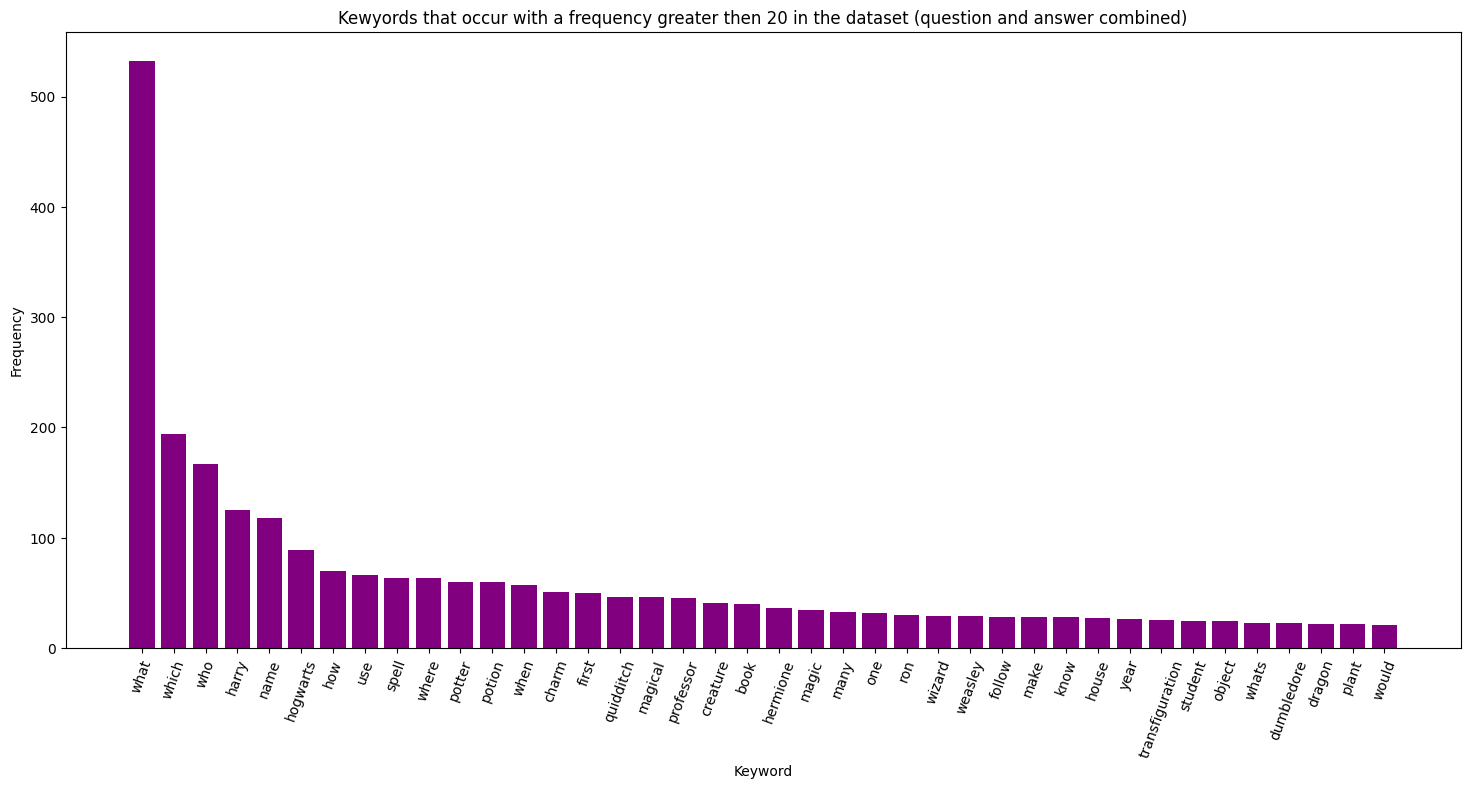

In [28]:
plt.figure(figsize=(18,8))

plt.bar(filtered_keyword_count_df['Keyword'], filtered_keyword_count_df['Frequency'], color="purple")

plt.xlabel('Keyword')
plt.ylabel('Frequency')
plt.title(f"Kewyords that occur with a frequency greater then {frequency_cutoff} in the dataset (question and answer combined)")
plt.xticks(rotation=70)
plt.show()

**Notes on keyword frequency**
1. The `what`, `which`, `who`, `name`, `how` and `where` are in top 10 of the frequency counts, so it looks like majority questions are likely to be factual types. These questions in all likelihood should have short answers. We can take a closer look at the dataset to confirm. `What` by far is the most common type of question keyword.
2. Its not a suprise that `harry` and `hogwarts` are also in the top - they would be the most common contextual keyword.
3. `spell` also might be a factual question? what kind of spell - may be check if all occurrence of spell are the factual question keywords? The same logic would be for `potion` and `charm`. 
4. There are some very wordy answers, it'll be interesting to look at their question format / type.
5. Note - `whats` and `would` also appear near the tail end of the graph although `would` questions could be quite open-ended?

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

### 6.2. Factual recall questions

In trivia, some of the most common questions are usually concerned with recalling facts (easy to obscure) to test the player.These questions would focus on asking about names, places, events, spells. 

From figure 3, we can see that the top five keywords are 'what' , 'which', 'who' along with 'harry' and 'name'. This is a strong indication that many questions could be *factual recall* types. So, we can expect these questions to have typical formats such 'What is Albus Dumbledore's full name?" or "Where did Harry live during the summer holidays?".  We can assess the occurence of such typical keywords in the `question keywords` along with their frequency. These keywords could be:

- "Who...?" -> related to a character name.
- "What...?" -> an object, fact, event
- "Where...?" -> a location
- "When...?" / "In what year...?" -> would relate a timing of an event (books timeline)
- "How many...?" -> Number (although 'how' on its own can be open-ended. so might have to check for presence of both)
- "Name the..." -> a list / name(s)

#### Section 6.2 quick links

[6.2.1. Distribution of factual recall type questions](#621-Distribution-of-factual-recall-type-questions)<br>
[6.2.2. What do the "what" questions look like?](#622-What-do-the-what-questions-look-like)<br>
[6.2.3. What do the "who" questions look like? ](#623-What-do-the-who-questions-look-like)<br>
[6.2.4. What do the "where" questons look like?](#624-What-do-the-where-questions-look-like)<br>
[6.2.5. What do the "when" questions look like?](#625-what-do-when-questions-look-like)<br>

In [29]:
# Parameters for analysis:
df_for_analysis = trivia_keywords_df
n_samples = 20

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

#### 6.2.1. Distribution of factual recall type questions 

Now let's take a wider look at the dataset and see how many answers we can consider to be *factual recall* . We can create a list of words to look for. The list might not be exhaustive but will gives us a good sense of the dataset.

In [30]:
# list of words to look for when identifying 'factual recall' questions 
factual_recall_list = ['what', 'name', 'who', 'where', 'when', 'whats']

# Initialize column:
trivia_keywords_df['factual_recall_keyword'] = None

# iterate through each row and notes how many keywords are present from the list and records them in the new `factual_recall_keyword` 
# column using list comprehension, else label as 'N/A'.
trivia_keywords_df['factual_recall_keyword'] = trivia_keywords_df['question keywords'].apply(
    lambda x: [word for word in factual_recall_list if word in x] or 'N/A'
)

In [31]:
trivia_keywords_df.head()

,question,answer,question keywords,answer keywords,combined_unique_keywords,factual_recall_keyword
0,What are the three European wizarding schools that participate in the Triwizard Tournament?,"Hogwarts, Beauxbatons, and Durmstrang.","[tournament, triwizard, three, what, wizarding, european, school, participate]","[beauxbatons, hogwarts, durmstrang]","[tournament, school, hogwarts, triwizard, three, what, beauxbatons, european, wizarding, durmstrang, participate]",[what]
1,When was Hogwarts founded?,10th century,"[found, hogwarts, when]","[th, century]","[hogwarts, th, century, found, when]",[when]
2,What is a Wronski Feint?,Pretending to dive for the Snitch,"[feint, wronski, what]","[pretend, dive, snitch]","[snitch, feint, dive, wronski, what, pretend]",[what]
3,You wouldn't know anything about this. Name a method to make your broom go faster.,Using polish,"[method, faster, broom, go, wouldnt, anything, name, make, know]","[polish, use]","[method, faster, polish, go, wouldnt, anything, make, use, name, broom, know]",[name]
4,Harry first took the Knight Bus in The Prisoner of Azkaban. How much does a ticket cost if it includes hot chocolate?,14 sickles.,"[azkaban, prisoner, how, first, take, knight, chocolate, cost, much, bus, hot, ticket, include, harry]",[sickle],"[azkaban, harry, prisoner, take, first, knight, chocolate, sickle, cost, much, bus, hot, ticket, include, how]",N/A


In [32]:
## How many of the records have vs. don't have a 'N/A' tag for the 'factual_recall_keyword'?

# where 'factual_recall_keyword' is N/A
not_factual_q_count = trivia_keywords_df[trivia_keywords_df['factual_recall_keyword']=='N/A']['question'].count()
not_factual_q_percentage = (not_factual_q_count / trivia_keywords_df.shape[0]) * 100
# where 'factual_recall_keyword' is not N/A
factual_q_count = trivia_keywords_df.shape[0] - not_factual_q_count
factual_q_percentage = 100 - not_factual_q_percentage

# display results
print("Factual recall questions:\n",
      f"- There are at least {factual_q_count} questions ({factual_q_percentage: .0f}% of total count) that can be considered factual recall types.\n",
      f"- There are {not_factual_q_count} questions ({not_factual_q_percentage: .0f}% of total count) that can be considered as not being factual recall types."
)

Factual recall questions:
 - There are at least 802 questions ( 74% of total count) that can be considered factual recall types.
 - There are 283 questions ( 26% of total count) that can be considered as not being factual recall types.


In [33]:
## How are the factual questions distributed?

# 1. Create a dictionary to store values for easy plotting
factq_dict = {}
total = trivia_keywords_df.shape[0]

for keyword in factual_recall_list:
    # check if keyword contains a list and then if keyword is in the list:
    filter_condition = lambda x: keyword in x if isinstance(x, list) else False
    count = trivia_keywords_df[trivia_keywords_df['factual_recall_keyword'].apply(filter_condition)].shape[0]
    factq_dict[keyword] = {
        'count': count,
        'percentage of total': (count / total) * 100
    }


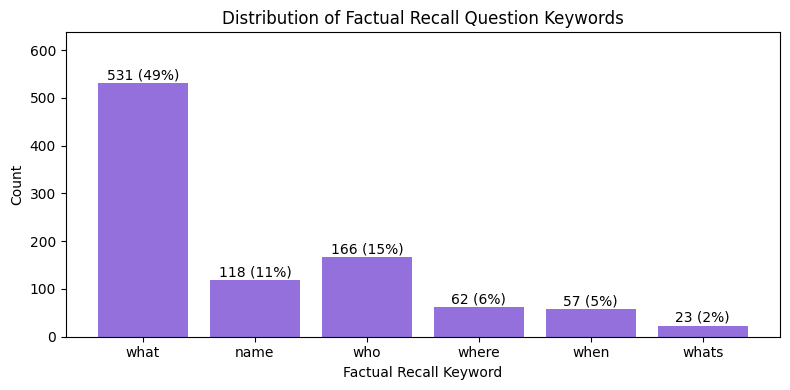

In [34]:
# 2. Visualize as a barchart 

# Gather data from dict
keywords = list(factq_dict.keys())
counts = [factq_dict[k]['count'] for k in keywords]
percentages = [factq_dict[k]['percentage of total'] for k in keywords]

# Plot
plt.figure(figsize=(8, 4))
bars = plt.bar(keywords, counts, color='mediumpurple' )

# Add "count (n%)"" labels above bars
for bar, count, pct in zip(bars, counts, percentages):
    label = f"{count} ({pct:.0f}%)"
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             label, ha='center', va='bottom', fontsize=10)

# Axis labels and title
plt.ylabel("Count")
plt.xlabel("Factual Recall Keyword")
plt.title(f"Distribution of Factual Recall Question Keywords")
plt.ylim(0, max(counts) * 1.2)  # Add some space above bars

plt.tight_layout()
plt.show()

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-62-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.2 Quick Links</a>

#### 6.2.2 What do the `"what"` questions look like?

Let's start by looking at "What" type questions as they are the most common (as per figure 3).

In [35]:
q_keyword = "what"
eda.get_question_type_info(df_for_analysis,q_keyword, n_samples)

There are 531 'what'-type questions in the data set ( 49% of total).
These questions have answers that range in lengths between 2 and 125.

Basic descriptive statistics of the answers with 'what' type questions: 
 count    531.000000
mean      15.589454
std       13.022368
min        2.000000
25%        8.000000
50%       12.000000
75%       18.000000
max      125.000000
Name: answer, dtype: float64

A random sample of the `what`- type questions: 


,question,answer,question keywords,answer keywords,combined_unique_keywords,factual_recall_keyword
1207,What does the Knitting Charm enchant?,The knitting needles.,"[enchant, knit, what, charm]","[knit, needle]","[enchant, what, knit, needle, charm]",[what]
1059,"In the book, what sport has Dudley recently taken up?",Boxing,"[take, dudley, what, book, sport, recently]",[boxing],"[take, dudley, what, book, sport, boxing, recently]",[what]
643,What is the name of the Hogwarts caretaker who is always complaining about the students?,Argus Filch,"[hogwarts, caretaker, who, student, what, complain, name, always]","[argus, filch]","[hogwarts, caretaker, filch, who, student, argus, what, complain, name, always]","[what, name, who]"
698,What is the name of the street where the Dursleys live?,Privet Drive,"[live, where, what, street, name, dursleys]","[privet, drive]","[privet, live, where, drive, what, street, name, dursleys]","[what, name, where]"
832,What do I hate most of all?,Myths and Legends,"[hate, what]","[myth, legend]","[hate, myth, what, legend]",[what]
457,And what about his pet dragon?,Norbert,"[pet, dragon, what]",[norbert],"[norbert, dragon, pet, what]",[what]
1275,What form of magical transportation is illegal?,Flying carpets,"[illegal, form, what, transportation, magical]","[fly, carpet]","[illegal, form, what, transportation, fly, carpet, magical]",[what]
615,What type of cauldron do first-year students need?,Pewter,"[need, firstyear, student, what, cauldron, type]",[pewter],"[need, student, what, pewter, cauldron, firstyear, type]",[what]
676,"What is the counter spell for Accio, Summoning Charm?",Depulso,"[accio, counter, spell, what, summon, charm]",[depulso],"[depulso, accio, counter, spell, what, summon, charm]",[what]
1165,What is the Patronus of Severus Snape?,Doe,"[snape, patronus, what, severus]",[doe],"[snape, patronus, what, doe, severus]",[what]


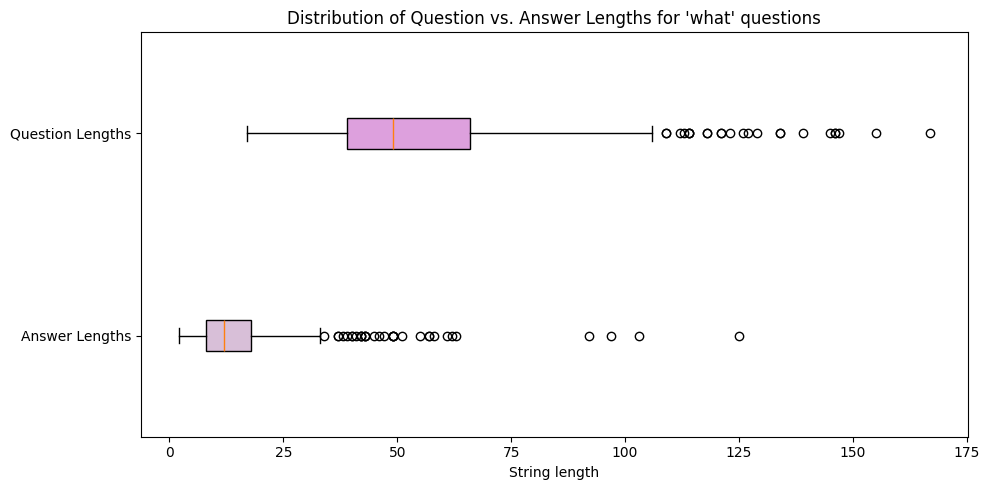

In [36]:
eda.create_ans_len_boxplot(df_for_analysis,q_keyword)

Ok, there is quite a range in answer length and we can't make any generalization about them. 

In [37]:
eda.print_keyword_ngrams(df_for_analysis['question'],'what',(2,5))


Analyzing common phrases (n-grams) starting with 'what' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'what':
- 'what is': 174
- 'what is the': 111
- 'what does': 50
- 'what is the name': 46
- 'what is the name of': 46
- 'what was': 27
- 'what did': 24
- 'what does the': 21
- 'what was the': 18
- 'what are': 17


In [64]:
# let's remove 'is', 'the', 'are', 'was' as our custom stop word list:
stop_words = ['is', 'the', 'are', 'was', 'does', 'did', 'do', 'kind', 'of', 'for','type'] 
eda.print_keyword_ngrams(df_for_analysis['question'],'what',(2,5), 10, stop_words)


Analyzing common phrases (n-grams) starting with 'what' in this set of questions:
Using stop_words: ['is', 'the', 'are', 'was', 'does', 'did', 'do', 'kind', 'of', 'for', 'type']
Top 10 common n-grams starting with 'what':
- 'what name': 63
- 'what spell': 17
- 'what magical': 16
- 'what creature': 15
- 'what incantation': 13
- 'what harry': 10
- 'what potion': 9
- 'what magical creature': 8
- 'what animal': 6
- 'what charm': 6


These N-grams also indicate that the "what" questions are asking for factual details.

Now let's also look at `name` keyword, it is the second-most frequent keyword but there might be an overlap with the `what` questions.

In [72]:
## What do questions with the 'name' keyword look like?

# Filter question that the word 'name' in them
name_questions = df_for_analysis.loc[df_for_analysis['question keywords'].apply(lambda x: keyword in x)]

# Now filter that subset of question to find the occurence of "name" without "what" / "what's" present.
name_nowhat_questions = name_questions[
    ~name_questions['question keywords'].apply(lambda x: 'what' in x or 'whats' in x)
]
# display results
print("Occurence of 'name' without 'what' in the trivia questions: ",name_nowhat_questions.shape[0])

Occurence of 'name' without 'what' in the trivia questions:  0


It look like that in this dataset "name" always appears with "what". So we don't have to consider them separately for now. However, it is entirely possible to phrase the question with just "name", e.g. "Name the characters from ....." and can be possible when the dataset is expanded.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-62-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.2 Quick Links</a>

#### 6.2.3. What do the `"who"` questions look like?

Let's start by looking at "What" type questions as they are the most common (as per figure 3).

In [108]:
# What do "who" questions look like? 
eda.get_question_type_info(df_for_analysis,"who", n_samples)

There are 166 'who'-type questions in the data set ( 15% of total).
These questions have answers that range in lengths between 4 and 84.

Basic descriptive statistics of the answers with 'who' type questions: 
 count    166.000000
mean      17.036145
std       11.996915
min        4.000000
25%       12.000000
50%       14.000000
75%       17.000000
max       84.000000
Name: answer, dtype: float64

A random sample of the `who`- type questions: 


,question,answer,question keywords,answer keywords,combined_unique_keywords,factual_recall_keyword
672,Who is the conductor of the Frog Choir?,Filius Flitwick,"[who, conductor, choir, frog]","[flitwick, filius]","[frog, who, conductor, flitwick, filius, choir]",[who]
590,"Who do you prefer: Dust, Binns, or Peeves?",Peeves!,"[binns, prefer, who, dust, peeve]",[peeve],"[binns, prefer, who, dust, peeve]",[who]
310,Who did Harry overhear in the Three Broomsticks talking about how Sirius Black betrayed his parents?,"Professor Flitwick, Professor McGonagall, Hagrid, Cornelius Fudge and Madam Rosmerta","[parent, how, who, betrayed, three, sirius, overhear, broomstick, black, talk, harry]","[madam, rosmerta, hagrid, fudge, flitwick, professor, mcgonagall, cornelius]","[madam, betrayed, who, hagrid, professor, mcgonagall, harry, rosmerta, sirius, flitwick, overhear, broomstick, talk, three, cornelius, parent, fudge, black, how]",[who]
385,Who kills Dobby?,Bellatrix Lestrange,"[who, kill, dobby]","[lestrange, bellatrix]","[who, dobby, lestrange, kill, bellatrix]",[who]
1138,Who makes laws for the magical world?,The Ministry of Magic.,"[law, world, who, make, magical]","[ministry, magic]","[law, world, who, magic, ministry, make, magical]",[who]
1118,Hermione places a jinx on the piece of parchment members of Dumbledore’s Army sign. What happens to those who betray the group?,Pustules will form the word sneak across their foreheads.,"[hermione, jinx, dumbledores, happen, who, army, parchment, member, what, betray, place, group, piece, sign]","[sneak, form, pustule, forehead, across, word]","[jinx, sneak, happen, who, betray, place, forehead, sign, hermione, parchment, group, across, word, dumbledores, army, form, pustule, piece, member, what]","[what, who]"
98,"During the Triwizard Tournament, who escorted Hermione to the Yule Ball?",Viktor Krum,"[tournament, hermione, escort, triwizard, who, ball, yule]","[krum, viktor]","[tournament, hermione, escort, triwizard, viktor, who, krum, ball, yule]",[who]
31,Who founded Hogsmeade Village?,Hengist of Woodcroft,"[who, village, found, hogsmeade]","[hengist, woodcroft]","[hengist, village, who, woodcroft, found, hogsmeade]",[who]
577,Who does Bill Weasley marry?,Fleur Delacour,"[who, weasley, marry, bill]","[delacour, fleur]","[weasley, who, fleur, delacour, marry, bill]",[who]
664,Who is Ravenclaw's patron ghost?,The Grey Lady,"[who, ravenclaws, ghost, patron]","[lady, grey]","[ravenclaws, lady, ghost, who, patron, grey]",[who]


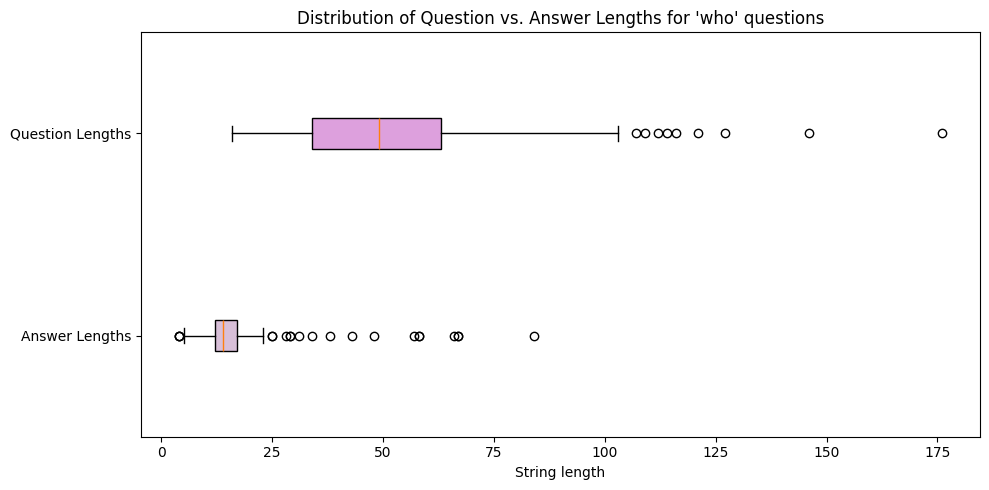

In [109]:
eda.create_ans_len_boxplot(df_for_analysis,"who")

**Note**: Although we know there is considerable overlap between 'what' and 'name' - 'name' remains in assessment for completeness.

In [110]:
# With no stop_words considered:
eda.print_keyword_ngrams(df_for_analysis['question'],"who", (2,5))


Analyzing common phrases (n-grams) starting with 'who' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'who':
- 'who is': 56
- 'who is the': 38
- 'who was': 20
- 'who was the': 12
- 'who wrote': 8
- 'who does': 7
- 'who invented': 5
- 'who is harry': 4
- 'who teaches': 4
- 'who created': 3


In [111]:
# Using a custom list of stop words.
stop_words = ['is', 'was', 'does', 'the', 'of', 'in']
eda.print_keyword_ngrams(df_for_analysis['question'],"who", (3,7), stop_words=stop_words)


Analyzing common phrases (n-grams) starting with 'who' in this set of questions:
Using stop_words: ['is', 'was', 'does', 'the', 'of', 'in']
Top 10 common n-grams starting with 'who':
- 'who headmaster hogwarts': 6
- 'who harry potter': 3
- 'who harry potter godfather': 3
- 'who original owner': 3
- 'who created sorcerer': 2
- 'who created sorcerer stone': 2
- 'who destroyed horcrux': 2
- 'who destroyed horcrux helga': 2
- 'who divination professor': 2
- 'who flying instructor': 2


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-62-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.2 Quick Links</a>

#### 6.2.4. What do the "where" questions look like? 

In [42]:
eda.get_question_type_info(df_for_analysis, "where", n_samples)

There are 62 'where'-type questions in the data set ( 6% of total).
These questions have answers that range in lengths between 4 and 77.

Basic descriptive statistics of the answers with 'where' type questions: 
 count    62.000000
mean     17.983871
std      12.387847
min       4.000000
25%      12.000000
50%      15.000000
75%      19.000000
max      77.000000
Name: answer, dtype: float64

A random sample of the `where`- type questions: 


,question,answer,question keywords,answer keywords,combined_unique_keywords,factual_recall_keyword
1080,Where do first-years have Herbology class?,Greenhouse One,"[where, firstyears, class, herbology]","[one, greenhouse]","[greenhouse, where, firstyears, herbology, one, class]",[where]
698,What is the name of the street where the Dursleys live?,Privet Drive,"[live, where, what, street, name, dursleys]","[privet, drive]","[privet, live, where, drive, what, street, name, dursleys]","[what, name, where]"
160,Where is the Slytherin Common Room?,The Dungeons,"[where, room, common, slytherin]",[dungeon],"[dungeon, room, common, slytherin, where]",[where]
166,Where does Harry Potter first see Draco Malfoy?,In Madame Malkin’s Robes for All Occasions,"[where, potter, first, draco, malfoy, see, harry]","[robes, madame, occasion, malkins]","[harry, occasion, robes, where, potter, malfoy, first, madame, malkins, see, draco]",[where]
1036,And where do the Weasleys go on holiday with their winnings?,Egypt,"[winning, where, weasleys, go, holiday]",[egypt],"[winning, where, weasleys, go, holiday, egypt]",[where]
978,What is the name of the place where students buy their school supplies?,Diagon Alley,"[supply, where, student, what, place, name, school, buy]","[diagon, alley]","[supply, diagon, where, student, what, place, name, school, buy, alley]","[what, name, where]"
650,What was the name of the orphanage where Lord Voldemort grew up?,Wool's Orphanage,"[lord, where, grow, what, name, orphanage, voldemort]","[wool, orphanage]","[lord, grow, where, what, wool, name, orphanage, voldemort]","[what, name, where]"
1013,"In the book, where do Hermione Granger’s parents move to?",Australia,"[hermione, parent, where, grangers, book, move]",[australia],"[hermione, parent, where, grangers, book, australia, move]",[where]
1205,Where do Harry Potter and Cho Chang have their first kiss?,In the Room of Requirement,"[chang, cho, where, potter, first, kiss, harry]","[room, requirement]","[chang, room, cho, first, potter, where, requirement, kiss, harry]",[where]
719,Where do monks grow gravity-resistant trees?,Nepal,"[monk, gravityresistant, where, grow, tree]",[nepal],"[monk, gravityresistant, where, grow, tree, nepal]",[where]


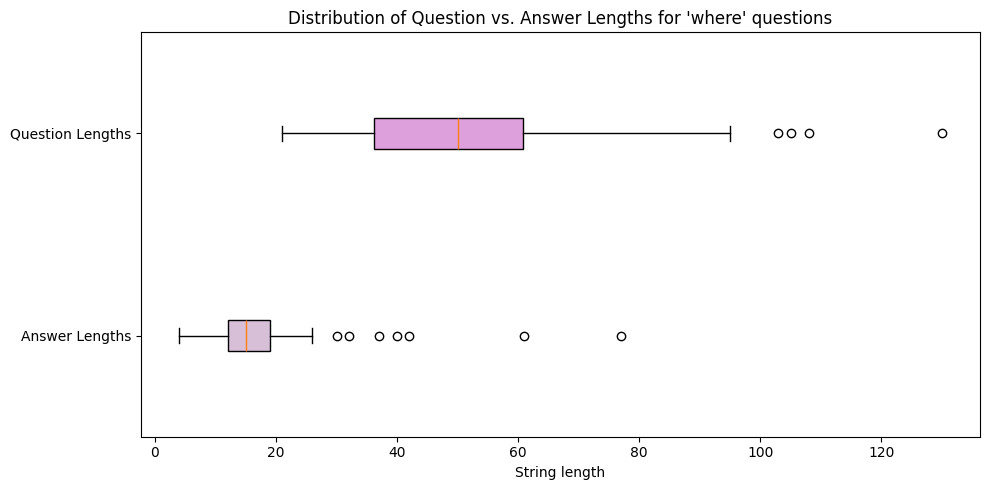

In [43]:
eda.create_ans_len_boxplot(df_for_analysis,"where")

In [89]:
eda.print_keyword_ngrams(df_for_analysis['question'], "where")


Analyzing common phrases (n-grams) starting with 'where' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'where':
- 'where is': 14
- 'where is the': 12
- 'where did': 9
- 'where do': 8
- 'where does': 8
- 'where was': 5
- 'where are': 4
- 'where can': 3
- 'where was harry': 3
- 'where are the': 2


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-62-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.2 Quick Links</a>

#### 6.2.5. What do "when" questions look like?

In [44]:
eda.get_question_type_info(df_for_analysis,"when",n_samples)

There are 57 'when'-type questions in the data set ( 5% of total).
These questions have answers that range in lengths between 3 and 62.

Basic descriptive statistics of the answers with 'when' type questions: 
 count    57.000000
mean     15.631579
std      13.271386
min       3.000000
25%       6.000000
50%      12.000000
75%      18.000000
max      62.000000
Name: answer, dtype: float64

A random sample of the `when`- type questions: 


,question,answer,question keywords,answer keywords,combined_unique_keywords,factual_recall_keyword
464,"When Professor Snape takes over Professor Lupin’s Defense Against the Dark Arts class, which page does he ask the students to turn to?",Page 394 (the page on werewolves),"[snape, dark, take, student, lupin, turn, art, defense, professor, page, ask, class, which, when]","[werewolf, page]","[snape, dark, werewolf, take, student, lupin, turn, art, defense, professor, page, ask, class, which, when]",[when]
924,"When Neville Longbottom dresses his Boggart (Professor Snape) up in his grandmother’s clothes, what stuffed bird is on top of the hat?",A vulture,"[snape, neville, stuff, dress, bird, clothe, what, longbottom, hat, boggart, professor, grandmother, when, top]",[vulture],"[snape, neville, stuff, dress, bird, clothe, what, hat, boggart, when, professor, grandmother, vulture, longbottom, top]","[what, when]"
357,What name was Harry Potter using when he was captured at Malfoy Manor by the Death Eaters?,Vernon Dudley,"[capture, eater, potter, malfoy, manor, what, use, name, death, when, harry]","[dudley, vernon]","[capture, eater, potter, malfoy, dudley, manor, what, vernon, use, name, death, when, harry]","[what, name, when]"
89,What does it mean when a magical creature is classified as XXX by the Ministry of Magic?,Competent Wizards Should Cope,"[creature, classify, magic, what, xxx, ministry, mean, when, magical]","[cope, competent, wizard]","[cope, creature, competent, magical, classify, xxx, what, ministry, wizard, mean, when, magic]","[what, when]"
228,What do all the hands on the Weasleys’s magical clock point to when Harry gets to the Burrow?,“Mortal peril”,"[weasleyss, clock, harry, point, get, what, burrow, hand, when, magical]","[mortal, peril]","[weasleyss, clock, mortal, point, magical, get, peril, what, burrow, hand, when, harry]","[what, when]"
12,How old was Luna when she lost her mom?,Nine,"[old, lose, mom, luna, when, how]",[nine],"[nine, old, lose, mom, luna, when, how]",[when]
983,"When Hermione Granger is found Petrified, she is not alone. Who is with her?",Penelope Clearwater,"[hermione, granger, who, alone, find, petrified, when]","[penelope, clearwater]","[hermione, granger, who, alone, find, penelope, petrified, clearwater, when]","[who, when]"
298,When is Neville's birthday?,July 30,"[birthday, nevilles, when]",[july],"[birthday, nevilles, when, july]",[when]
614,What piece of equipment is essential when re-potting baby Mandrakes?,Earmuffs,"[mandrake, essential, baby, what, repot, piece, equipment, when]",[earmuff],"[earmuff, mandrake, essential, what, repot, piece, baby, equipment, when]","[what, when]"
254,What did Hermione use to help heal Ron's arm when it got splinched?,Essence of Dittany,"[hermione, get, what, heal, when, use, ron, splinched, help, arm]","[dittany, essence]","[hermione, dittany, get, what, heal, use, ron, splinched, arm, help, essence, when]","[what, when]"


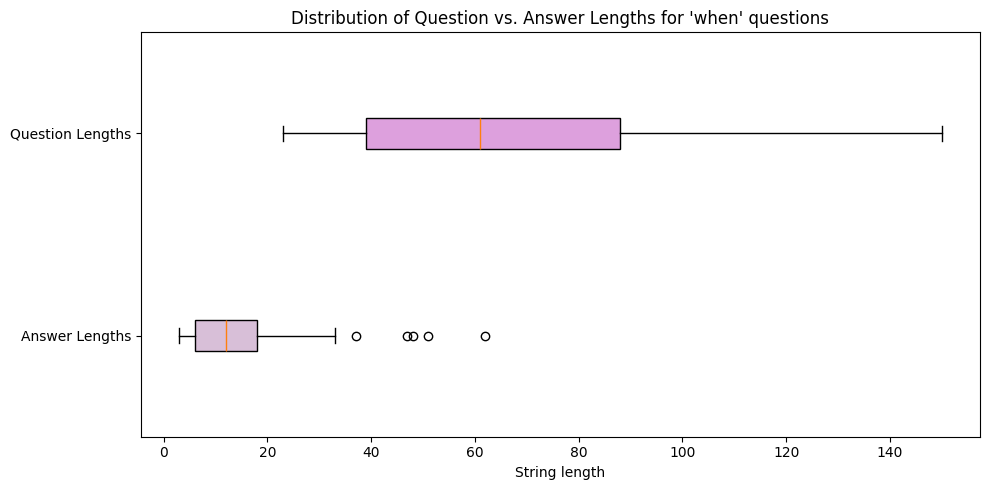

In [45]:
eda.create_ans_len_boxplot(df_for_analysis,"when")

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-62-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.2 Quick Links</a>

### 6.3 Questions that do not have factual recall keywords

The 'factual recall keywords' is not exhaustive. So looking at the questions with an 'N/A' tag can help us:
1. Determine if any other keywords should be added to the list added to the list that we might not have caught this time.
2. Is there a pattern in the remaining questions? what kind of questions are they? 
3. Are these open-ended type questions? e.g."Why....?" or "Would...?"

We can start looking at the tokens specific to this subset of the data frame and how frequently they occur.

#### Section 6.3 quick links

[6.3.1. What do the "which" questions look like?](#631-what-do-the-which-questions-look-like)<br>
[6.3.2. What do the "who" questions look like?](#632-what-do-the-why-questions-look-like)<br>
[6.3.3. What do the "how" questions look like?](#633-what-do-the-how-type-questions-look-like)<br>
[6.3.4. How many questions contain multiple keywords? ](#634-how-many-questions-contain-multiple-keywords)<br>
[6.3.5. What do the remaining "N/A" questions look like? ](#635-what-do-the-remaining-na-questions-look-like)<br>
[6.3.6. Plan of action ](#636-plan-of-action)

In [46]:
# What are the common tokens in the N/A tagged questions?

# A. Filter the relevant questions where the 'factual_recall_keyword' is 'N/A'
q_filtered_df = trivia_keywords_df[trivia_keywords_df['factual_recall_keyword']=='N/A']
q_filtered_df.sample(10)

,question,answer,question keywords,answer keywords,combined_unique_keywords,factual_recall_keyword
771,Where’s Peeves favorite place to swim?,Boys’ ground floor toilets,"[swim, favorite, place, wheres, peeve]","[boy, ground, toilet, floor]","[toilet, swim, favorite, place, floor, boy, ground, wheres, peeve]",N/A
88,Which Quidditch team is last in the league?,Chudley Cannons,"[quidditch, league, last, team, which]","[cannon, chudley]","[league, quidditch, cannon, last, team, which, chudley]",N/A
120,How many classes did Hermione Granger take this year?,12!,"[granger, hermione, year, take, many, class, how]",[],"[granger, hermione, year, take, many, class, how]",N/A
189,Which puzzle guarding the Sorcerer’s Stone does Hermione Granger solve?,Professor Snape’s logic puzzle with potion bottles,"[hermione, granger, solve, puzzle, stone, guard, sorcerer, which]","[potion, bottle, puzzle, logic, snapes, professor]","[hermione, granger, solve, potion, bottle, puzzle, stone, which, logic, snapes, professor, sorcerer, guard]",N/A
494,Which was my Tonks favourite band?,The Weird Sisters,"[favourite, which, band, tonks]","[sister, weird]","[sister, band, favourite, tonks, which, weird]",N/A
1237,Which Hogwarts house does Luna Lovegood belong to?,Ravenclaw,"[hogwarts, belong, house, lovegood, luna, which]",[ravenclaw],"[hogwarts, belong, ravenclaw, house, lovegood, luna, which]",N/A
1122,Which potion would make Rowan feel better?,Pepperup Potion.,"[would, well, potion, feel, rowan, which, make]","[potion, pepperup]","[would, well, feel, potion, rowan, which, make, pepperup]",N/A
758,Which creature was used in Quidditch before being replaced by the Golden Snitch?,Golden Snidget,"[creature, snitch, quidditch, use, replace, which, golden]","[golden, snidget]","[creature, snidget, snitch, quidditch, use, replace, which, golden]",N/A
630,An intended transformation is directly influenced by which of the following?,Concentration,"[influence, directly, follow, intend, which, transformation]",[concentration],"[concentration, influence, directly, follow, intend, which, transformation]",N/A
97,Which is not the form of Transfiguration?,Enchantment,"[which, transfiguration, form]",[enchantment],"[which, transfiguration, form, enchantment]",N/A


In [47]:
# B. Count the occurence of each question token

# 1. create a copy so original df is not modified.
na_frq_df = q_filtered_df[['question', 'question keywords']].copy()

# 2. Use  the explode method to expand the list into individual column entries:
na_q_df = na_frq_df.explode('question keywords')

# 3. Now we can count values of the each token occurence in the `question keywords` column:
na_q_counts = na_q_df['question keywords'].value_counts()

# 3. print results
# Rename the index and values columns for clarity:
na_q_counts.index.name = "keyword"
na_q_counts.name = "Frequency"
total_na_q = q_filtered_df.shape[0]

print(f'* There are a total of {total_na_q} questions that are tagged as "N/A" in the "factual_recall_keywords" column.\n')
print("* Summary of the 'N/A' question keyword tokens (cutoff to display only with counts > 10): \n")
print(na_q_counts[na_q_counts>10])

# print percentage of 'which' and 'why' keywords:
which_q_percent_of_na = (na_q_counts['which'] / total_na_q) * 100
why_q_percent_of_na =  (na_q_counts['why'] / total_na_q) * 100

print(f"\n* Percentage of 'which' questions in the 'N/A' filtered dataset: {which_q_percent_of_na: .1f}%")
print(f"* Percentage of 'why' questions in the 'N/A' filtered dataset: {why_q_percent_of_na: .1f}%")

* There are a total of 283 questions that are tagged as "N/A" in the "factual_recall_keywords" column.

* Summary of the 'N/A' question keyword tokens (cutoff to display only with counts > 10): 

keyword
which        188
how           61
many          30
spell         25
use           25
follow        23
hogwarts      22
harry         22
quidditch     21
potion        21
charm         15
would         14
one           12
why           12
first         11
plant         11
Name: Frequency, dtype: int64

* Percentage of 'which' questions in the 'N/A' filtered dataset:  66.4%
* Percentage of 'why' questions in the 'N/A' filtered dataset:  4.2%


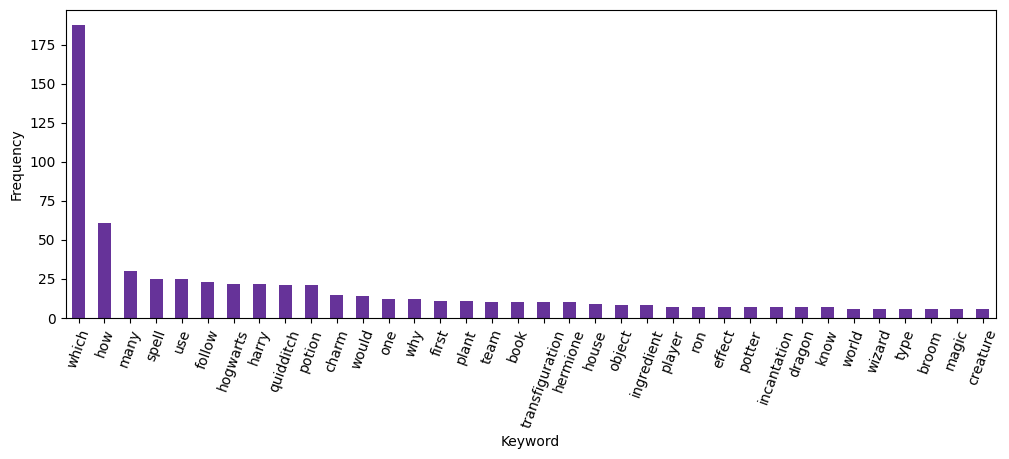

In [48]:
## We can plot it to get a better idea visually

# update figure_count for visual:
# figure_count += 1

# Lets filter for values greater than a threshold so the chart isn't cluttered by the tail
threshold = 5
high_frequency_tokens = na_q_counts[na_q_counts > threshold]

high_frequency_tokens.plot(kind='bar', figsize=(12,4), color='rebeccapurple')

plt.xlabel('Keyword')
plt.ylabel('Frequency')
# plt.title(f"Figure {figure_count}. Kewyords that occur with a frequency greater then {frequency_cutoff} in the dataset (question and answer combined)")
plt.xticks(rotation=70)
plt.show()

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-63-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.3 Quick Links</a>

#### 6.3.1. What do the "which" questions look like?

In [49]:
eda.get_question_type_info(df_for_analysis,"which",n_samples)

There are 194 'which'-type questions in the data set ( 18% of total).
These questions have answers that range in lengths between 2 and 75.

Basic descriptive statistics of the answers with 'which' type questions: 
 count    194.000000
mean      14.824742
std       10.151199
min        2.000000
25%        8.000000
50%       13.000000
75%       18.000000
max       75.000000
Name: answer, dtype: float64

A random sample of the `which`- type questions: 


,question,answer,question keywords,answer keywords,combined_unique_keywords,factual_recall_keyword
6,Which of these is an ingredient in Befuddlement Draughts?,Sneezewort,"[befuddlement, which, ingredient, draught]",[sneezewort],"[draught, ingredient, sneezewort, befuddlement, which]",N/A
987,Which member of the Council became the first Minister of Magic?,Ulick Gamp,"[become, first, member, council, minister, which, magic]","[ulick, gamp]","[become, first, member, council, minister, ulick, which, gamp, magic]",N/A
956,Which elective is occasionally offered at Hogwarts?,Alchemy,"[offer, hogwarts, occasionally, elective, which]",[alchemy],"[offer, hogwarts, occasionally, elective, which, alchemy]",N/A
726,Which of the following would be the easiest Transfiguration?,Porcupine to Pincushion,"[would, transfiguration, easiest, follow, which]","[pincushion, porcupine]","[would, transfiguration, easiest, pincushion, follow, porcupine, which]",N/A
372,"In the Quidditch World Cup, Ireland's team had three main chasers: Mullet, Troy, and Moran. Which one scored the first goal?",Troy,"[main, world, mullet, chaser, first, goal, three, score, quidditch, moran, which, one, cup, team, irelands, troy]",[troy],"[main, world, mullet, chaser, first, goal, three, score, quidditch, moran, irelands, team, cup, one, which, troy]",N/A
247,The three D's of Apparition do not include which of the below?,Dimension,"[three, apparition, ds, which, include]",[dimension],"[dimension, three, apparition, ds, which, include]",N/A
984,Which of the following creatures eat Fairy Eggs?,Bowtruckles,"[creature, fairy, follow, which, egg, eat]",[bowtruckles],"[creature, bowtruckles, fairy, follow, which, egg, eat]",N/A
760,Which type of transfiguration is employed in this lesson?,Transformation,"[lesson, transfiguration, employ, which, type]",[transformation],"[lesson, transfiguration, employ, which, transformation, type]",N/A
543,Which of these spells can summon an object?,Accio,"[which, object, spell, summon]",[accio],"[accio, spell, object, summon, which]",N/A
830,Myomancy involves observation of which creatures?,Mice and rats,"[creature, myomancy, involve, observation, which]","[rat, mouse]","[creature, rat, myomancy, mouse, involve, observation, which]",N/A


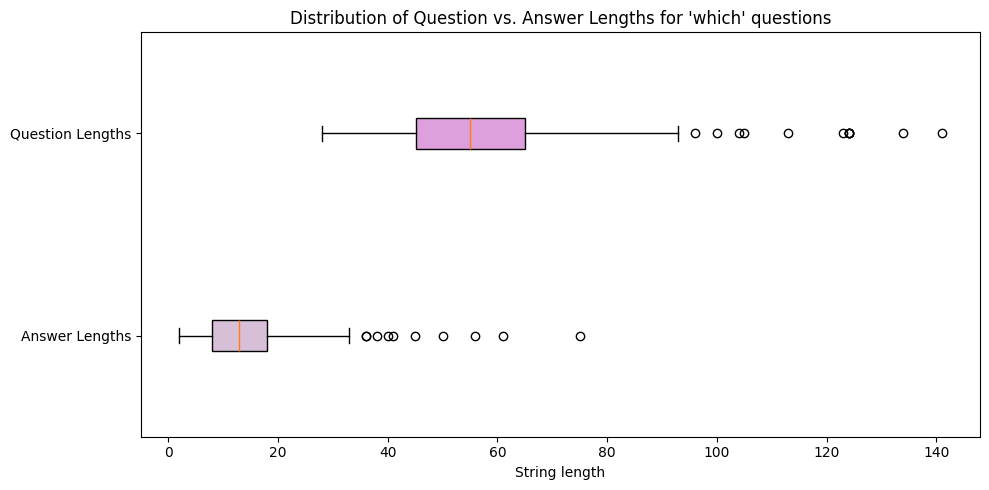

In [50]:
eda.create_ans_len_boxplot(df_for_analysis,"which")

In [51]:
eda.print_keyword_ngrams(df_for_analysis['question'],'which',(2,4))


Analyzing common phrases (n-grams) starting with 'which' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'which':
- 'which of': 65
- 'which of these': 38
- 'which of the': 25
- 'which of the following': 22
- 'which of these is': 11
- 'which is': 10
- 'which of these spells': 8
- 'which potion': 7
- 'which spell': 7
- 'which incantation': 6


In [52]:
eda.print_keyword_ngrams(df_for_analysis['question'],"which",(5,10))


Analyzing common phrases (n-grams) starting with 'which' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'which':
- 'which of the following is': 8
- 'which of these is not': 6
- 'which of the following is not': 5
- 'which of these spells is': 4
- 'which of these is an': 3
- 'which of these is not type': 3
- 'which of these is not type of': 3
- 'which of these scenarios would': 3
- 'which of these scenarios would you': 3
- 'which of these scenarios would you use': 3


**Observations: "Which" type questions**

- Marjority of the 'N/A' tagged questions are `which` type questions (194 questions). 
- In general we can expect `which` questions to be open-ended questions, but a closer look at these questions in the dataset confirms that they are also another form of a `factual recall question`.
- This in turn means that, with the inclusion of `which` into the keyword list, the vast majority of the questions (97%) can be considered as 'factual recall type questions' within this dataset.
- The longest answer is a list of characters full names.
- The sampled question generally seem to be difficult.

>NOTE: Can convert 👇🏼 code into a custom function later.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-63-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.3 Quick Links</a>

#### 6.3.2. What do the "why" questions look like?

In [53]:
eda.get_question_type_info(df_for_analysis,"why", n_samples)

There are 12 'why'-type questions in the data set ( 1% of total).
These questions have answers that range in lengths between 13 and 87.

Basic descriptive statistics of the answers with 'why' type questions: 
 count    12.000000
mean     32.083333
std      23.294394
min      13.000000
25%      18.500000
50%      24.500000
75%      33.250000
max      87.000000
Name: answer, dtype: float64

A random sample of the `why`- type questions: 


,question,answer,question keywords,answer keywords,combined_unique_keywords,factual_recall_keyword
968,Why do Ron Weasley and Hermione Granger stop speaking?,"Ron blames Hermione’s cat, Crookshanks, for the disappearance of his pet rat, Scabbers.","[hermione, weasley, granger, why, speaking, ron, stop]","[rat, disappearance, blame, crookshanks, cat, scabbers, ron, pet, hermiones]","[hermione, weasley, granger, rat, disappearance, blame, why, crookshanks, cat, scabbers, speaking, ron, pet, hermiones, stop]",N/A
400,Why did students think Harry was the Heir of Slytherin?,He can speak Parseltongue.,"[slytherin, student, think, why, heir, harry]","[parseltongue, speak]","[parseltongue, slytherin, speak, student, think, why, heir, harry]",N/A
9,Why did student initially think Harry was the Heir of Slytherin?,He can speak Parseltongue,"[slytherin, student, think, why, heir, initially, harry]","[parseltongue, speak]","[parseltongue, slytherin, speak, student, think, why, initially, heir, harry]",N/A
644,Why did the Werewolf Code of Conduct fail?,No Werewolves Signed,"[fail, conduct, code, why, werewolf]","[werewolf, sign]","[fail, code, why, conduct, werewolf, sign]",N/A
1121,Why did Hermione miss the lesson on Cheering Charms?,Draco's cruel behavior led her to miss the class.,"[hermione, miss, lesson, why, cheer, charm]","[miss, behavior, cruel, lead, class, draco]","[class, hermione, miss, lesson, behavior, draco, cruel, why, lead, cheer, charm]",N/A
1228,Why did the Werewolf Code of Conduct fail?,No werewolves signed it.,"[fail, conduct, code, why, werewolf]","[werewolf, sign]","[fail, code, why, conduct, werewolf, sign]",N/A
1020,Why shouldn't you drop Puffapod beans?,They'll bloom,"[puffapod, bean, why, drop, shouldnt]","[bloom, theyll]","[puffapod, bloom, bean, why, drop, shouldnt, theyll]",N/A
122,Why would you need to switch brooms midair?,Broom failure,"[would, need, why, midair, switch, broom]","[failure, broom]","[would, need, failure, why, midair, switch, broom]",N/A
770,Why does Neville Longbottom faint in Herbology class?,"His earmuffs were loose, so he heard the cry of the baby mandrake.","[neville, faint, why, herbology, class, longbottom]","[hear, earmuff, mandrake, loose, baby, cry]","[hear, earmuff, mandrake, neville, loose, faint, why, cry, herbology, baby, class, longbottom]",N/A
110,Which of the following was a reason why the 14th century witch burnings were pointless?,Flame-Freezing Charm,"[th, century, burning, why, witch, reason, follow, pointless, which]","[charm, flamefreezing]","[flamefreezing, th, century, burning, why, witch, reason, follow, pointless, which, charm]",N/A


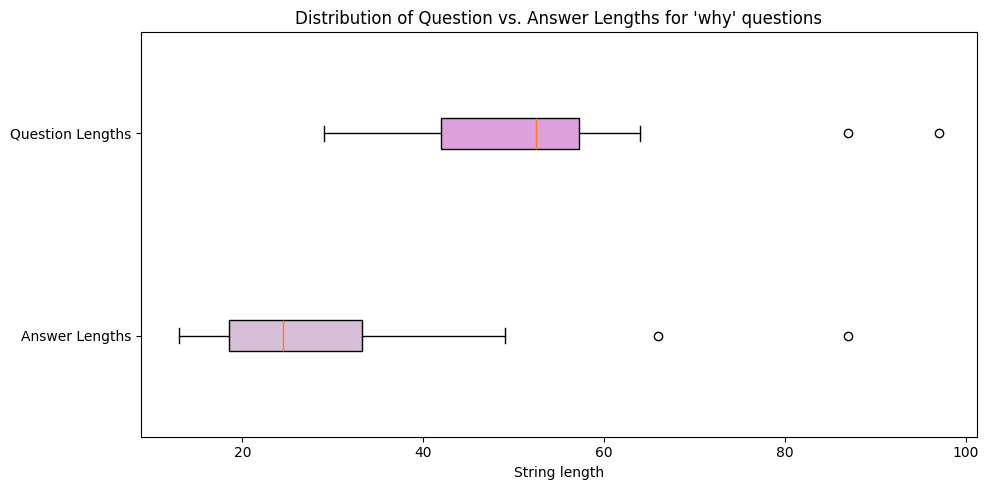

In [54]:
eda.create_ans_len_boxplot(df_for_analysis,"why")

**Observations:"why" type questions**
- From the token count we know that there are 12 `why` type questions in the filtered dataset and the full dataset (1% of the total).
- The answers to these questions are generally long, ranging between 13 to 87 words in general.
- These questions seem more open-ended with answers that can vary for players and would require interpretation.

[[Back to TOC]](#table-of-contents)

#### 6.3.3. What do the "how" type questions look like?

In [55]:
eda.get_question_type_info(df_for_analysis,"how",n_samples)

There are 70 'how'-type questions in the data set ( 6% of total).
These questions have answers that range in lengths between 1 and 124.

Basic descriptive statistics of the answers with 'how' type questions: 
 count     70.000000
mean      16.871429
std       24.547453
min        1.000000
25%        3.250000
50%        9.000000
75%       17.750000
max      124.000000
Name: answer, dtype: float64

A random sample of the `how`- type questions: 


,question,answer,question keywords,answer keywords,combined_unique_keywords,factual_recall_keyword
1125,How long should a Polyjuice Potion stew before usage?,One Month,"[long, potion, usage, polyjuice, stew, how]","[one, month]","[month, long, potion, usage, one, polyjuice, stew, how]",N/A
93,How many Horcruxes did Voldemort create intentionally?,Six,"[horcruxes, intentionally, many, voldemort, create, how]",[six],"[horcruxes, intentionally, many, voldemort, create, six, how]",N/A
186,How is the Grey Lady related to Rowena Ravenclaw?,She's Rowena's daughter.,"[lady, relate, rowena, ravenclaw, grey, how]","[rowenas, daughter, shes]","[lady, relate, rowena, daughter, ravenclaw, shes, rowenas, grey, how]",N/A
784,How many players are on a Quidditch team?,Seven,"[player, quidditch, many, team, how]",[seven],"[player, quidditch, many, seven, team, how]",N/A
529,How did Mad-Eye Moody punish Draco Malfoy for trying to Hex Harry?,He turned Draco into a ferret.,"[try, harry, how, malfoy, madeye, hex, punish, moody, draco]","[ferret, turn, draco]","[try, ferret, harry, draco, malfoy, madeye, hex, turn, punish, moody, how]",N/A
4,Harry first took the Knight Bus in The Prisoner of Azkaban. How much does a ticket cost if it includes hot chocolate?,14 sickles.,"[azkaban, prisoner, how, first, take, knight, chocolate, cost, much, bus, hot, ticket, include, harry]",[sickle],"[azkaban, harry, prisoner, take, first, knight, chocolate, sickle, cost, much, bus, hot, ticket, include, how]",N/A
999,How many possible Quidditch fouls are there?,700,"[quidditch, many, possible, foul, how]",[],"[possible, quidditch, many, foul, how]",N/A
1028,How do you get into the Room of Requirement?,"While thinking about what you need the room to become, walk past where it should be three times.","[room, get, requirement, how]","[become, room, need, time, where, think, past, three, what, walk]","[become, room, need, time, where, think, get, past, requirement, three, what, walk, how]",N/A
518,How many siblings does Ron Weasley have?,Six,"[weasley, many, ron, sibling, how]",[six],"[weasley, six, many, ron, sibling, how]",N/A
188,How do you greet a Hippogriff?,With a bow,"[hippogriff, greet, how]",[bow],"[bow, hippogriff, greet, how]",N/A


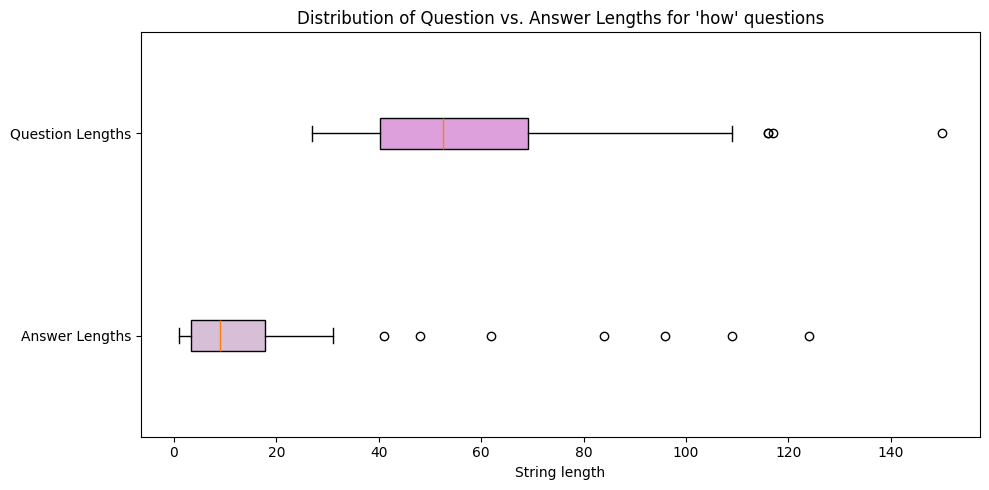

In [56]:
eda.create_ans_len_boxplot(df_for_analysis,"how")

**Observations: "how" type questions**: 


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-63-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.3 Quick Links</a>

#### 6.3.4. How many questions contain multiple keywords?

In [ ]:
## How many questions have multiple keywords?
condition_1 = trivia_keywords_df['factual_recall_keyword']!='N/A'
condition_2 = trivia_keywords_df['factual_recall_keyword'].str.len() > 1

filter = trivia_keywords_df[condition_1 & condition_2]
percentage = (filter['question'].count() / trivia_keywords_df.shape[0]) * 100
print(f"There are {filter.shape[0]} ({percentage: .0f}% of total) questions with multiple factual type keywords. \n")
print("Data frame preview: ")
filter.sample(20)

There are 139 ( 13% of total) questions with multiple factual type keywords. 

Data frame preview: 


,question,answer,question keywords,answer keywords,combined_unique_keywords,factual_recall_keyword
660,What is the name of the Gryffindor ghost?,Nearly Headless Nick.,"[name, ghost, what, gryffindor]","[nick, nearly, headless]","[ghost, nick, nearly, what, gryffindor, name, headless]","[what, name]"
263,"In the book version of Harry Potter and the Sorcerer's Stone, what is the name of Dudley's friend who goes to the zoo with the Dursleys and Harry?",Piers,"[who, potter, friend, zoo, dudleys, what, go, book, version, stone, name, dursleys, sorcerer, harry]",[pier],"[who, potter, pier, zoo, friend, dudleys, what, go, book, version, stone, name, dursleys, sorcerer, harry]","[what, name, who]"
766,What does Harry do when he grows up?,He works as an Auror for the Ministry of Magic.,"[grows, when, what, harry]","[work, auror, ministry, magic]","[magic, what, ministry, work, grows, auror, when, harry]","[what, when]"
123,"What is the name of the werewolf who teaches Defense Against the Dark Arts in ""Harry Potter and the Prisoner of Azkaban""?",Remus Lupin,"[azkaban, teach, dark, prisoner, who, potter, what, art, defense, name, werewolf, harry]","[remus, lupin]","[azkaban, teach, dark, prisoner, who, potter, lupin, what, art, defense, remus, name, werewolf, harry]","[what, name, who]"
438,Voldemort stole Helga Hufflepuff's cup from an old woman named Hepzibah Smith. What was the name of her house-elf?,Hokey.,"[woman, hepzibah, smith, what, hufflepuffs, steal, old, name, cup, voldemort, houseelf, helga]",[hokey],"[hokey, woman, hepzibah, smith, what, hufflepuffs, steal, old, helga, name, cup, voldemort, houseelf]","[what, name]"
524,"What spell does Harry discover written in the Half-Blood Prince's potions textbook in Book 6, and who invented it?","Sectumsempra, Severus Snape.","[halfblood, spell, who, write, potion, what, invent, book, discover, prince, textbook, harry]","[sectumsempra, snape, severus]","[halfblood, snape, spell, who, write, potion, what, invent, book, discover, sectumsempra, prince, severus, textbook, harry]","[what, who]"
1060,What name does Buckbeak get after being saved from execution?,Witherwings,"[get, what, save, name, buckbeak, execution]",[witherwings],"[witherwings, get, what, save, name, buckbeak, execution]","[what, name]"
447,What is the name of the three-headed dog guarding the trapdoor in Harry Potter and the Sorcerer's Stone?,Fluffy,"[potter, threeheaded, what, dog, stone, name, trapdoor, sorcerer, guard, harry]",[fluffy],"[potter, threeheaded, fluffy, what, dog, stone, name, trapdoor, sorcerer, guard, harry]","[what, name]"
1014,Who is the Headmaster of Hogwarts when Harry arrives?,Albus Dumbledore.,"[hogwarts, who, arrive, headmaster, when, harry]","[albus, dumbledore]","[albus, hogwarts, who, dumbledore, arrive, headmaster, when, harry]","[who, when]"
580,What is the name of the wizarding prison in the Harry Potter series?,Azkaban,"[potter, what, wizarding, series, name, prison, harry]",[azkaban],"[azkaban, potter, what, series, name, wizarding, prison, harry]","[what, name]"


Not surprising that 'what' and 'name' appear together several times, with 'where' popping up too — so there's some overlap between these keywords. However, in these overlapping cases, the question always starts with 'what' — the dominant keyword.

It's fairly clear that the majority of questions in this dataset are factual recall (74%), and among those, what questions (49%) related to objects, events, facts, and character names are the most common.

>**NOTE**:
>A second pass that includes combinations of two or more keywords would be useful. Considering counts without overlap?
<br>

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-63-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.3 Quick Links</a>

#### 6.3.5 What do the remaining 'N/A' questions look like?

We will use the `q_filter_df` because this dataframe only contain the questions that were tagged as 'N/A' in the 'factual_recall_keywords' column. Here we only want columns that do not have `which` or `why` as a keyword.

In [57]:
# Filter condition:
remaining_na_condition = q_filtered_df['question keywords'].apply(
    lambda x: all(word not in x for word in ['why', 'which','how'])
)
remaining_na_questions_df = q_filtered_df.loc[remaining_na_condition]

# Display results
print("Number of questions that are not 'which' or 'why' type but tagged as 'N/A': ", remaining_na_questions_df.shape[0])
print("Sample of questions: \n")
remaining_na_questions_df

Number of questions that are not 'which' or 'why' type but tagged as 'N/A':  23
Sample of questions: 



,question,answer,question keywords,answer keywords,combined_unique_keywords,factual_recall_keyword
28,"""Lemon Drop"" is the password to whose office?",Dumbledore,"[whose, password, drop, office, lemon]",[dumbledore],"[whose, password, dumbledore, drop, office, lemon]",N/A
108,Did Muggles use ancient runes as well?,They did.,"[well, muggles, rune, use, ancient]",[],"[well, muggles, rune, ancient, use]",N/A
147,"On his first ride aboard the Hogwarts Express, whose card did Harry get with his chocolate frog?",Dumbledore,"[express, card, hogwarts, whose, frog, first, chocolate, get, aboard, ride, harry]",[dumbledore],"[express, card, hogwarts, frog, whose, harry, first, get, dumbledore, aboard, ride, chocolate]",N/A
389,True or false: Harry Potter and the Deathly Hallows: Part Two is the shortest Harry Potter movie.,True! The run time is just 130 minutes.,"[part, shortest, two, potter, movie, hallows, true, deathly, false, harry]","[run, time, true, minute]","[part, time, shortest, minute, two, movie, potter, hallows, true, run, deathly, false, harry]",N/A
419,Where's one place you would not find any gnomes?,Antarctica,"[would, gnome, place, find, one, wheres]",[antarctica],"[would, antarctica, gnome, place, find, one, wheres]",N/A
544,Fill in the blank: Petrificus Totalus is the incantation for the Full Body-Bind curse.,Bind (Got this in the Petrificus Totalus lesson.),"[blank, petrificus, totalus, full, curse, fill, incantation, bodybind]","[lesson, get, petrificus, totalus, bind]","[blank, lesson, bind, get, petrificus, totalus, full, curse, fill, incantation, bodybind]",N/A
601,True or false: This is the longest movie in the franchise.,"False! Harry Potter and the Chamber of Secrets is the longest movie, at 161 minutes.","[long, movie, true, franchise, false]","[minute, movie, potter, longest, secret, false, chamber, harry]","[minute, long, movie, potter, longest, true, secret, false, franchise, chamber, harry]",N/A
636,Wich of these creatures is notable proud and easy to offend if not treated politely?,Hippogriff,"[easy, creature, offend, notable, treat, politely, wich, proud]",[hippogriff],"[easy, creature, offend, hippogriff, notable, treat, politely, wich, proud]",N/A
667,The Bouncy Bulb is extremely difficult to...,Pot.,"[difficult, extremely, bouncy, bulb]",[pot],"[pot, bouncy, bulb, difficult, extremely]",N/A
681,"Whose teeth did Nearly Headless Nick accidentally turn into tusks, leading to his death?",Lady Grieve,"[accidentally, whose, nick, nearly, turn, tusk, lead, death, teeth, headless]","[lady, grieve]","[accidentally, lady, grieve, whose, nick, nearly, headless, turn, tusk, lead, teeth, death]",N/A



##### What are the remaining questions like?

- The use other keywords such as 'whose', 'can', 'did', 'does', 'do' , 'is it',  'wheres', 'whom' (variation not caught in list). Some of these words can be added to the list e.g. "whom", "wheres", "whose" but the other words are very ambiguous and may introduce noise in the keywords.
- indicative statements instead of questions - e.g. "Dittany, mixed with this ingredient, can cure a Werewolf bite." Ans: "Powdered Silver"
- nonsensical questions (not for trivia), e.g. Q: "Will you serve the great nation of Peevesland, soldier?", Ans: "Sir, yes, sir!"
- 2x True / false type.
- 1x fill-in-the-blank, e.g. Q:"Fill in the blank: Petrificus Totalus is the incantation for the Full Body-Bind curse." Ans: "Bind (Got this in the Petrificus Totalus lesson.)" <- thre is an error here though - no blank given in the question and it is very unclear what is being asked.
x

##### What can we do with these remaining questions?

There are now only 23 questions that have a 'N/A' questions. 
Should these questions be modified so one of the `factual_recall_keywords` can be applied?  This would mean changing the question wording to lead with an appropriate `factual_recall_keyword` where possible. But that would reduce variety and nuance in the dataset even if, right now, these type are only a small percentage of the questions. This also makes the analysis / game more flexible towards expanding the trivia Q&A dataset in future project phases.


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-63-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.3 Quick Links</a>

#### 6.3.6 Plan of Action

**Decision**: will not modify questions instead add additional keyword columns for other types of questions (open-ended, yes/no etc). 
    
So the **plan of action** is:

1. Filter/Remove: Identify and remove/flag 'Nonsensical' and known 'Problematic' (like the bad fill-in-the-blank and only one of its type) questions first.
2. Classify Yes/No: Check if the first word of the question is in your yes_no_keywords list. Tag as Yes/No.
3. Classify True/False: Check if answer text is 'True'/'False'. Also tag this as a Yes/No type.
4. Classify Factual Recall: Expand the factual_recall_keywords list and use it for tagging the dataset again (including what, who, where, when, which, whose, whom, wheres, name, how many etc.). Tag with Factual keyword.
5. Classify open-ended: Check if the first word is 'Why' or potentially 'How'<pending>. Tag as Explanatory.
6. Recheck remainder manually after tagging and decide what to do (tag unassigned? keep it flexible for future addition that way?
7. Determine the logic for then categorizing the questions using binary tag columns for each question type. Clarify logic for assigning tag. How will conflicts be handled when there are tags present from multiple question type categories? --> consider hierarchical, rule based approach.
8. With the addition of new columns, create a data dictionary of the finalized dataframe. Create the final data save checkpoint for the game version dataset to be used in the CLI MVP. Also create an accompanying data dictionary json file for the csv.

> NOTES: 
>- some questions are fill-in-the blanks (e.g q id 667: "The Bouncy Bulb is extremely difficult to ...")
>- others are random "fun" questions? e.g. (Q1271. "Will you serve the great nation of Peevesland, soldier?" - Ans: 'Sir, yes, sir!')
>- presented as statements (Q929: "Dittany, mixed with this ingredient, can cure a Werewolf bite.", Ans: "Powdered Silver")
>- Q.644 "Why did the Werewolf Code of Conduct fail?" and Q.1228 appear to be duplicates.

> Note: Have a look at the questions before and after 230 - Q.230 looks incomplete.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-63-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.3 Quick Links</a>

### 6.4 Common N-grams in the dataset

In [102]:
eda.print_common_ngrams(df_for_analysis['question'],(2,4), top_n=20)


Analyzing common phrases (n-grams) in this set of questions:
Top 20 common n-grams:
- 'harry potter': 48
- 'does harry': 17
- 'sorcerer stone': 13
- 'ministry magic': 12
- 'magical creature': 11
- 'triwizard tournament': 11
- 'quidditch team': 10
- 'did harry': 9
- 'draco malfoy': 9
- 'harry potter series': 9
- 'potter series': 9
- 'chamber secrets': 8
- 'common room': 8
- 'did hermione': 8
- 'professor snape': 8
- 'harry ron': 7
- 'hermione granger': 7
- 'polyjuice potion': 7
- 'does hermione': 6
- 'fred george': 6


In [59]:
eda.print_keyword_ngrams(df_for_analysis['question'],"why")


Analyzing common phrases (n-grams) starting with 'why' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'why':
- 'why did': 6
- 'why did the': 2
- 'why would': 2
- 'why would you': 2
- 'why did hermione': 1
- 'why did liechtenstein': 1
- 'why did student': 1
- 'why did students': 1
- 'why do': 1
- 'why do ron': 1


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 7. Extending the dataset with new question categorization columns

In [60]:
## Updated keyword lists for searching different types of questions.

# Factual recall: expanded list of words to look for when identifying 'factual recall' questions 
expanded_factual_recall_list = ['what', 'name', 'who', 'where', 'wheres', 'when', 'whats', 'whose']

# Open-ended: new list
open_ended_list = ['why', 'how']

# Yes/No: new list
# in questions: 
yesno_question_start_keywords = ['is', 'are', 'was', 'were', 'do', 'does', 'did', 'can', 'could', 'has', 'had', 'will', 'would', 'should','True', 'False'] # in question
# validation check with answers
yesorno_list_forans = ['True', 'False', 'Yes', 'No'] # in answer

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 8. Summary

- Signifiant analysis and categorization of the questions types was achieved just by tokenizing the question and answers and looking at the question syntax. The trivia dataset follows question pattern of what can typically be expected and could be categorized into question types.
- The vast majority of the questions are factual-recall type (97%).  The answers to factual-recall type questions are relatively simpler to analyze for correctness.
- Of the 97%, majority (49%) of the factual-recall types use 'what' as a keyword to pharse the question. 
- There are other question formats in the dataset as well:
    - True / False or Yes / No -> binary choice
    - Fill in the blank
    - open-ended or explanatory
    - question written as statements
- There were no multiple-choice questions.
- There were also spelling mistakes and problematic (nonsensical) questions that needed to be cleaned. 
- A design decision was made not to modify or remove the uncategorized questions.
- The dataset right now is sufficient for the CLI-MVP.
- However, the data analysis so far has not taken into account 'Harry Potter' specific content. This will be tackled specifically in the next project phase using custom NER classes.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 9. Key findings

1. 97%+ successful categorization even before NER work - excellent success metric.
2. Similar contextual, "Harry Potter" centric categorization will help enrich the game experience and help make it more immersive.
2. The main distinguishing factor for questions in the dataset is whether they are 'factual-recall' type or not. These question types generally have straight forward answers. Answer comparison with user input should be relatively straight forward for the MVP.
4. When growing the dataset for next phases 
    - can balance the other question type categories (especially open-ended, nuanced questions to make NLP features shine)
    - add multiple choice questions especially for easy mode
    - Can also balance the categories within the 'factual-recall' - this will help with medium / difficult levels.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

---

<div align="center">
    <span style="color:purple; font-size:32px;">Part-4: Finalizing dataset for CLI-MVP</span>
</div>

## 10. Data dictionary

1. Data dictionary table
2. Json conversion for the csv

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 11. Next steps

Based on the work completed in this notebook:

1. **CLI MVP Input:** <br>
The dataset generated here, containing the cleaned trivia questions/answers and extracted keywords (from the second checkpoint), serves as the primary data source for the current command-line interface (CLI) MVP of the trivia game. 

2.  **Further Feature Enhancement (NER):**<br>
 The next phase of data enrichment involves applying Named Entity Recognition (NER) to potentially classify questions or extract structured information like difficulty and category. This work is planned for the [NER Implementation notebook](03-NER_implementation.ipynb)

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

---

#### 💾 Checkpoint 3: Phase-1 CLI-MVP dataset 

Saving clean dataset with keywords and question type tags
<details>
<summary> Click here for checkpoint details and <b>warning!</b> </summary>

The DataFrame is now cleaned, EDA completed, with the keywords and question-type features columns. Saving the current state.
<br>
> **⚠️ Caution: Manual Intervention Required for Saving Files**
>
> Please be aware that the `save_dataframe_to_csv` utility is designed to prevent accidental data loss. It **does not automatically overwrite** previously saved files.
>
> If you run a cell that calls this function and the output file (based on `filename_base`, `version`, and `subfolder`) already exists, the save operation will be skipped. You will see a message indicating this.
>
> **To save your latest data, you must manually intervene by either:**
> 1.  Deleting the older version of the CSV file from the file system.
> 2.  Modifying the `version` argument (or `filename_base`) in your function call to create a new, unique filename.

The following code saves the cleaned DataFrame to <code>data/project_datasets/</code> based on the selected `Save arguments` in the code below.
</div>
</details>

In [103]:
# Using utils.paths.py module -> prevents overwritting csv file unless manually done.

# Save arguments
# dataframe_to_save = 
name_for_csvfile = 'CLI-MVP_trivia_dataset'
csv_version = 'v0'
csv_subfolder = 'project_datasets'

# Save csv  file with custom functions and defined save arguments
# up.save_dataframe_to_csv(dataframe_to_save, name_for_csvfile, csv_version, csv_subfolder)

---

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#1-introduction" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Return to the Top</a>